In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

from src.sql_queries import (
    get_business_overview,
    get_monthly_revenue,
    get_revenue_by_category,
    get_revenue_by_state,
    get_customer_segmentation,
    get_order_status_summary,
    get_payment_analysis,
    get_review_analysis,
    get_orders_by_weekday,
    get_orders_by_hour,
    get_delivery_analysis,
    get_seller_performance,
)

print("Setup complete!")

Setup complete!


In [2]:
# Plot Settings
BG      = "#0F1117"
CARD_BG = "#1A1D27"
GRID_C  = "#2C2F3F"
TEXT_C  = "#E8EAF0"
BLUE    = "#3498DB"
GREEN   = "#2ECC71"
RED     = "#E74C3C"
ORANGE  = "#F39C12"
PURPLE  = "#9B59B6"

plt.rcParams.update({
    "figure.facecolor" : BG,
    "axes.facecolor"   : CARD_BG,
    "text.color"       : TEXT_C,
    "axes.labelcolor"  : TEXT_C,
    "xtick.color"      : TEXT_C,
    "ytick.color"      : TEXT_C,
    "axes.edgecolor"   : GRID_C,
    "grid.color"       : GRID_C,
    "font.family"      : "DejaVu Sans",
    "axes.titlesize"   : 12,
    "axes.titleweight" : "bold",
})

print("Plot settings applied!")

Plot settings applied!


2026-05-23 10:07:43 | INFO     | src.sql_queries | [OK] Q1: Business overview fetched


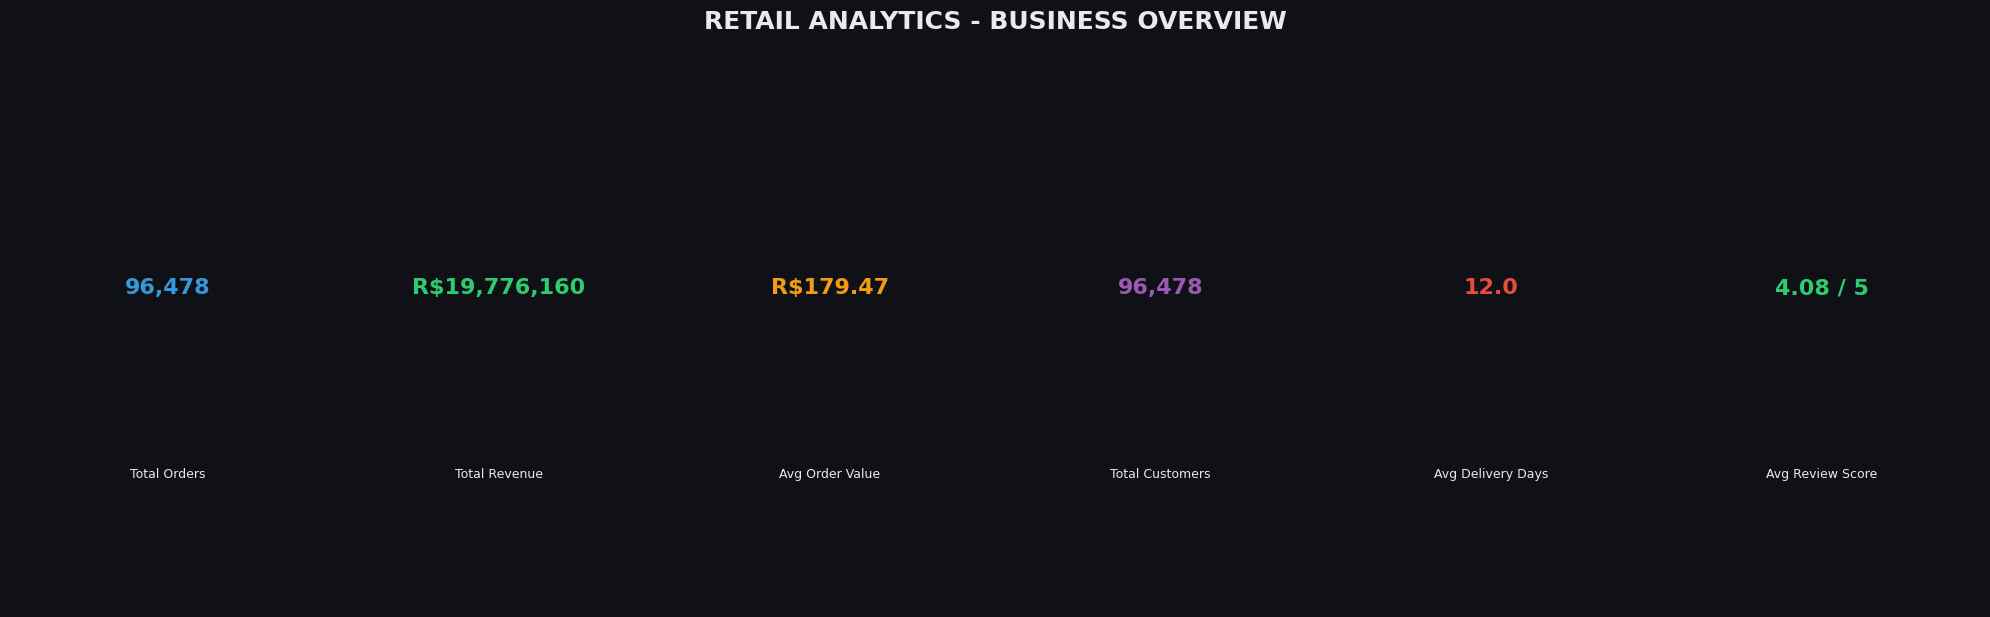

In [3]:
# Business Overview KPIs
df = get_business_overview()

fig = plt.figure(figsize=(20, 6), facecolor=BG)
fig.suptitle(
    "RETAIL ANALYTICS - BUSINESS OVERVIEW",
    fontsize=18, fontweight="bold",
    color=TEXT_C, y=1.02
)

kpis = [
    ("Total Orders",      f"{int(df['total_orders'].iloc[0]):,}",      BLUE),
    ("Total Revenue",     f"R${df['total_revenue'].iloc[0]:,.0f}",     GREEN),
    ("Avg Order Value",   f"R${df['avg_order_value'].iloc[0]:,.2f}",   ORANGE),
    ("Total Customers",   f"{int(df['total_customers'].iloc[0]):,}",   PURPLE),
    ("Avg Delivery Days", f"{df['avg_delivery_days'].iloc[0]:.1f}",    RED),
    ("Avg Review Score",  f"{df['avg_review_score'].iloc[0]:.2f} / 5", GREEN),
]

for i, (title, value, color) in enumerate(kpis):
    ax = fig.add_subplot(1, 6, i + 1)
    ax.set_facecolor(color + "22")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")
    ax.text(
        0.5, 0.60, value,
        ha="center", va="center",
        fontsize=16, fontweight="bold",
        color=color
    )
    ax.text(
        0.5, 0.25, title,
        ha="center", va="center",
        fontsize=9, color=TEXT_C
    )
    for spine in ["top", "right", "bottom", "left"]:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_color(color)
        ax.spines[spine].set_linewidth(2)

plt.tight_layout()
plt.show()

2026-05-23 10:11:59 | INFO     | src.sql_queries | [OK] Q2: Monthly revenue fetched


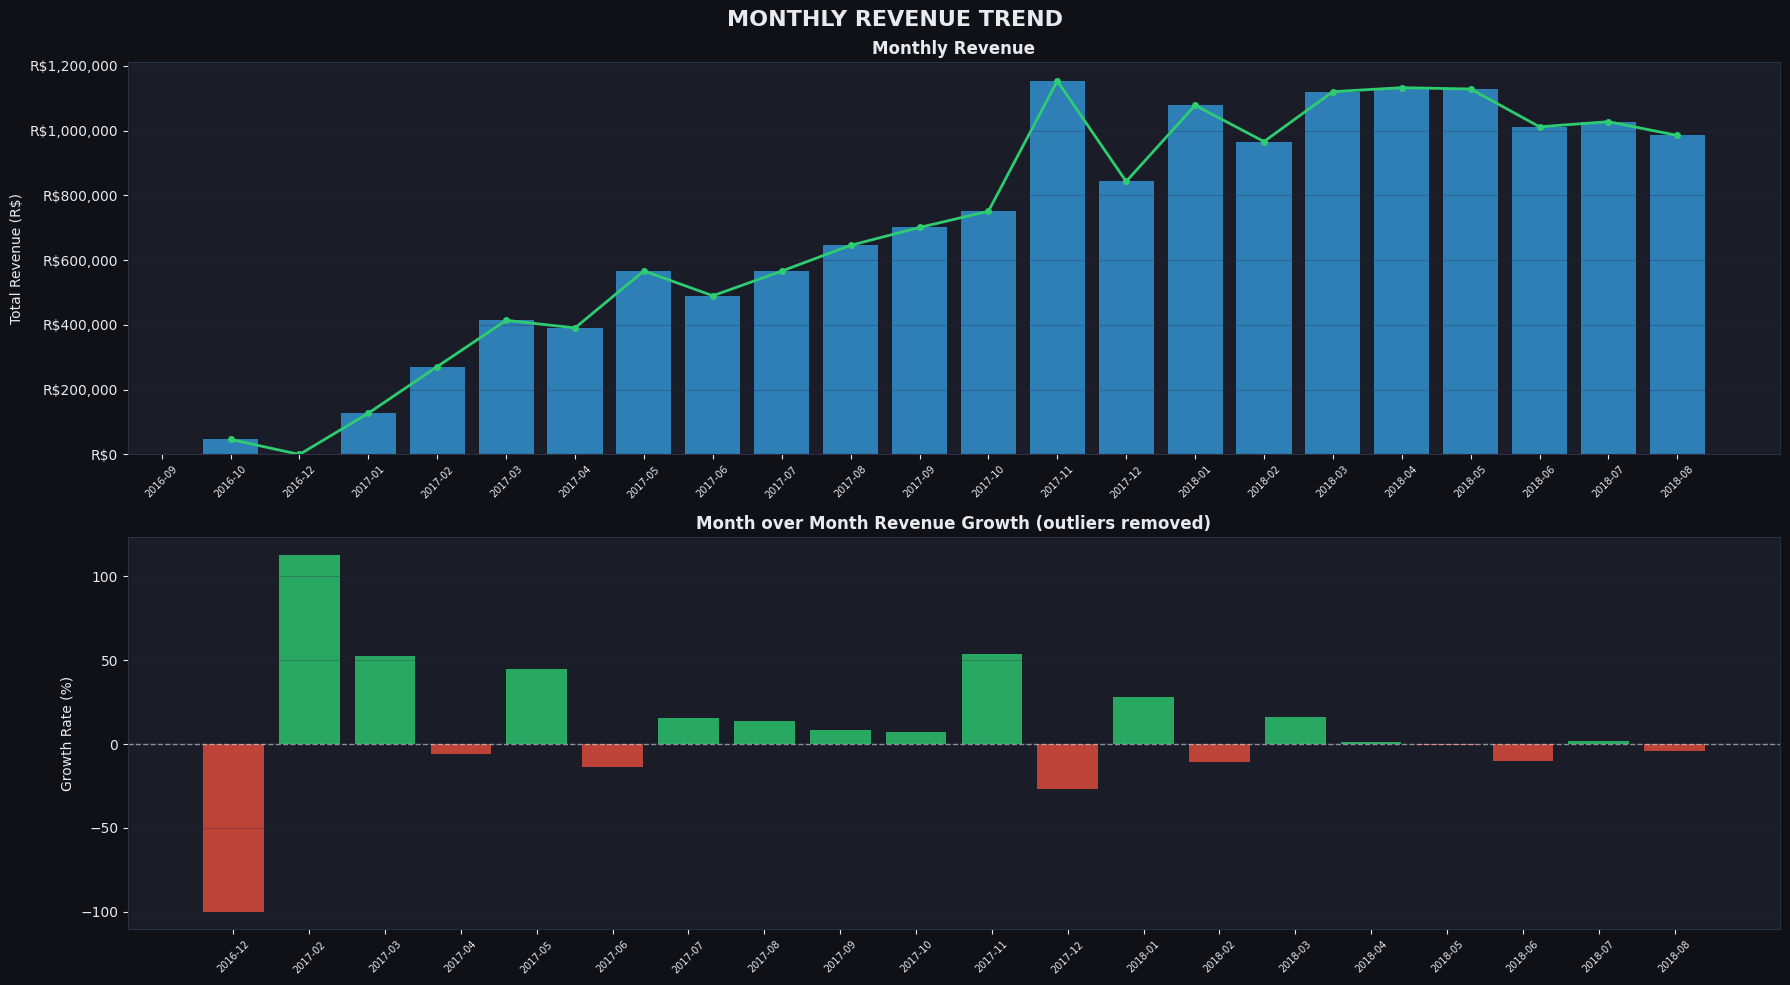

In [5]:
# Monthly Revenue Trend
df = get_monthly_revenue()

# Remove first row as it has no previous month to compare
df_growth = df[df["revenue_growth_pct"].notna()].copy()

# Remove outliers above 200%
df_growth = df_growth[df_growth["revenue_growth_pct"] < 200]

fig, axes = plt.subplots(2, 1, figsize=(18, 10), facecolor=BG)
fig.suptitle(
    "MONTHLY REVENUE TREND",
    fontsize=16, fontweight="bold", color=TEXT_C
)

# Plot 1: Revenue bars
ax = axes[0]
ax.bar(
    df["year_month"], df["total_revenue"],
    color=BLUE, alpha=0.8, edgecolor="none"
)
ax.plot(
    df["year_month"], df["total_revenue"],
    color=GREEN, lw=2, marker="o", ms=4
)
ax.set_ylabel("Total Revenue (R$)")
ax.set_title("Monthly Revenue")
ax.tick_params(axis="x", rotation=45, labelsize=7)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f"R${x:,.0f}")
)
ax.grid(axis="y", alpha=0.3)

# Plot 2: Growth rate (outliers removed)
ax = axes[1]
growth = df_growth["revenue_growth_pct"]
colors = [GREEN if v >= 0 else RED for v in growth]
ax.bar(
    df_growth["year_month"], growth,
    color=colors, alpha=0.8, edgecolor="none"
)
ax.axhline(0, color="white", lw=1, ls="--", alpha=0.5)
ax.set_ylabel("Growth Rate (%)")
ax.set_title("Month over Month Revenue Growth (outliers removed)")
ax.tick_params(axis="x", rotation=45, labelsize=7)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

2026-05-23 10:16:03 | INFO     | src.sql_queries | [OK] Q4: Revenue by category fetched


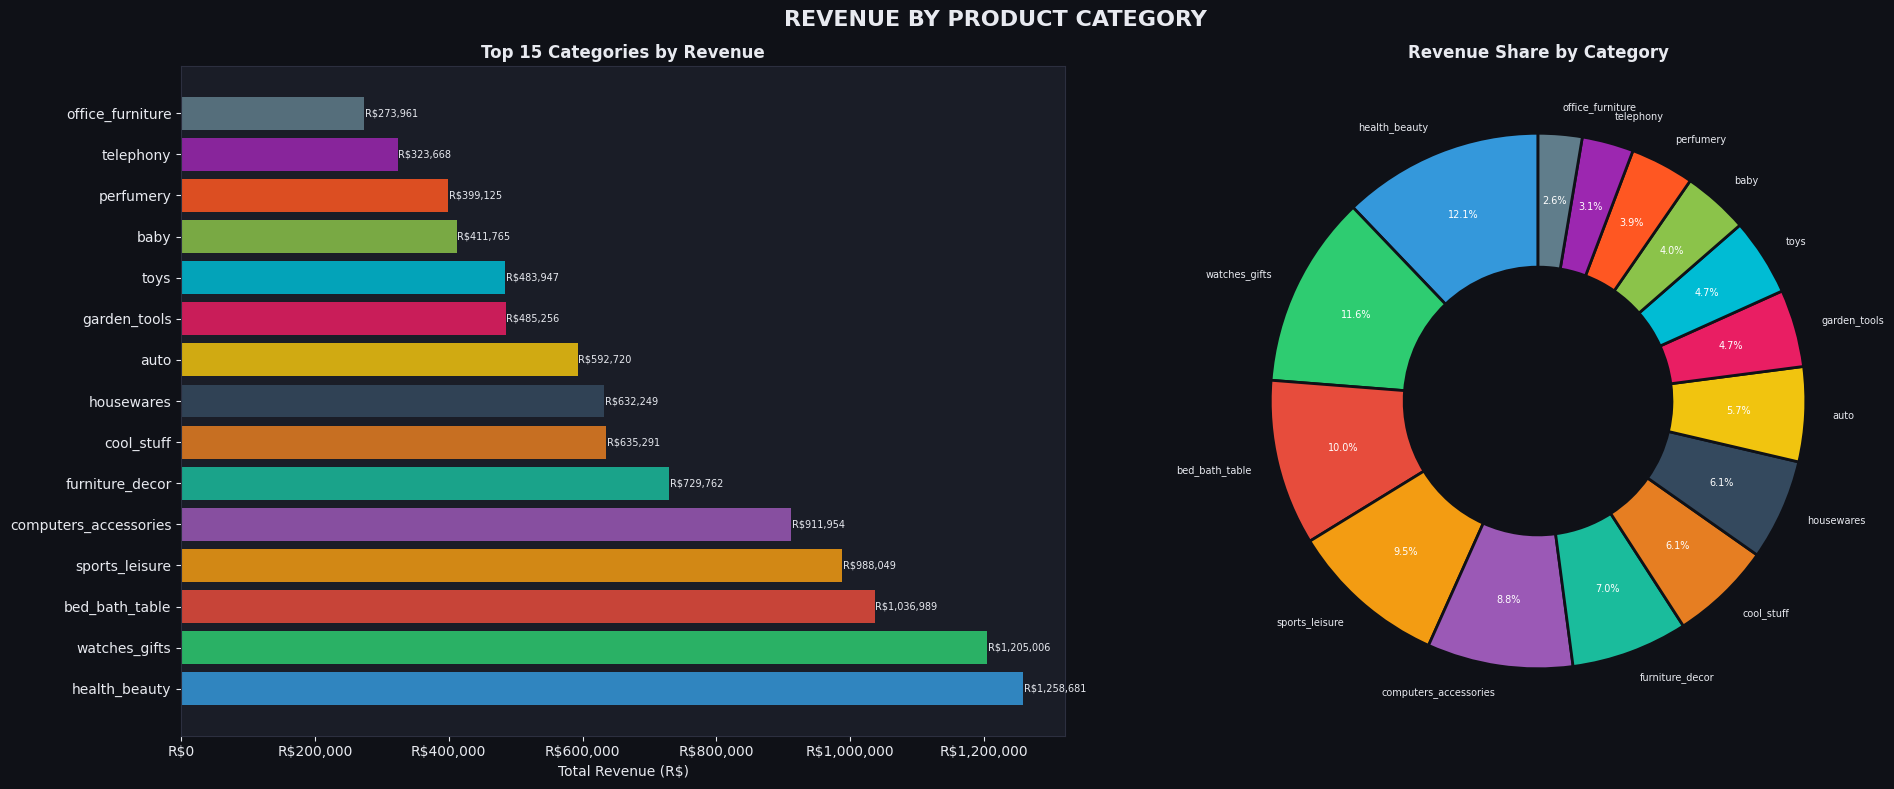

In [6]:
# Revenue by Category
df = get_revenue_by_category().head(15)

fig, axes = plt.subplots(1, 2, figsize=(20, 8), facecolor=BG)
fig.suptitle(
    "REVENUE BY PRODUCT CATEGORY",
    fontsize=16, fontweight="bold", color=TEXT_C
)

colors = [BLUE, GREEN, RED, ORANGE, PURPLE,
          "#1ABC9C", "#E67E22", "#34495E",
          "#F1C40F", "#E91E63", "#00BCD4",
          "#8BC34A", "#FF5722", "#9C27B0", "#607D8B"]

# Plot 1: Horizontal bar chart
ax = axes[0]
bars = ax.barh(
    df["category"], df["total_revenue"],
    color=colors[:len(df)], edgecolor="none", alpha=0.85
)
ax.set_xlabel("Total Revenue (R$)")
ax.set_title("Top 15 Categories by Revenue")
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f"R${x:,.0f}")
)
for bar, val in zip(bars, df["total_revenue"]):
    ax.text(
        val + 1000,
        bar.get_y() + bar.get_height() / 2,
        f"R${val:,.0f}",
        va="center", fontsize=7, color=TEXT_C
    )

# Plot 2: Revenue share donut
ax = axes[1]
wedges, texts, autotexts = ax.pie(
    df["revenue_share_pct"],
    labels=df["category"],
    autopct="%1.1f%%",
    colors=colors[:len(df)],
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(
        width=0.5,
        edgecolor=BG,
        linewidth=2
    )
)
for at in autotexts:
    at.set(fontsize=7, color="white")
for t in texts:
    t.set(fontsize=7, color=TEXT_C)
ax.set_title("Revenue Share by Category")

plt.tight_layout()
plt.show()

2026-05-23 10:18:06 | INFO     | src.sql_queries | [OK] Q5: Revenue by state fetched


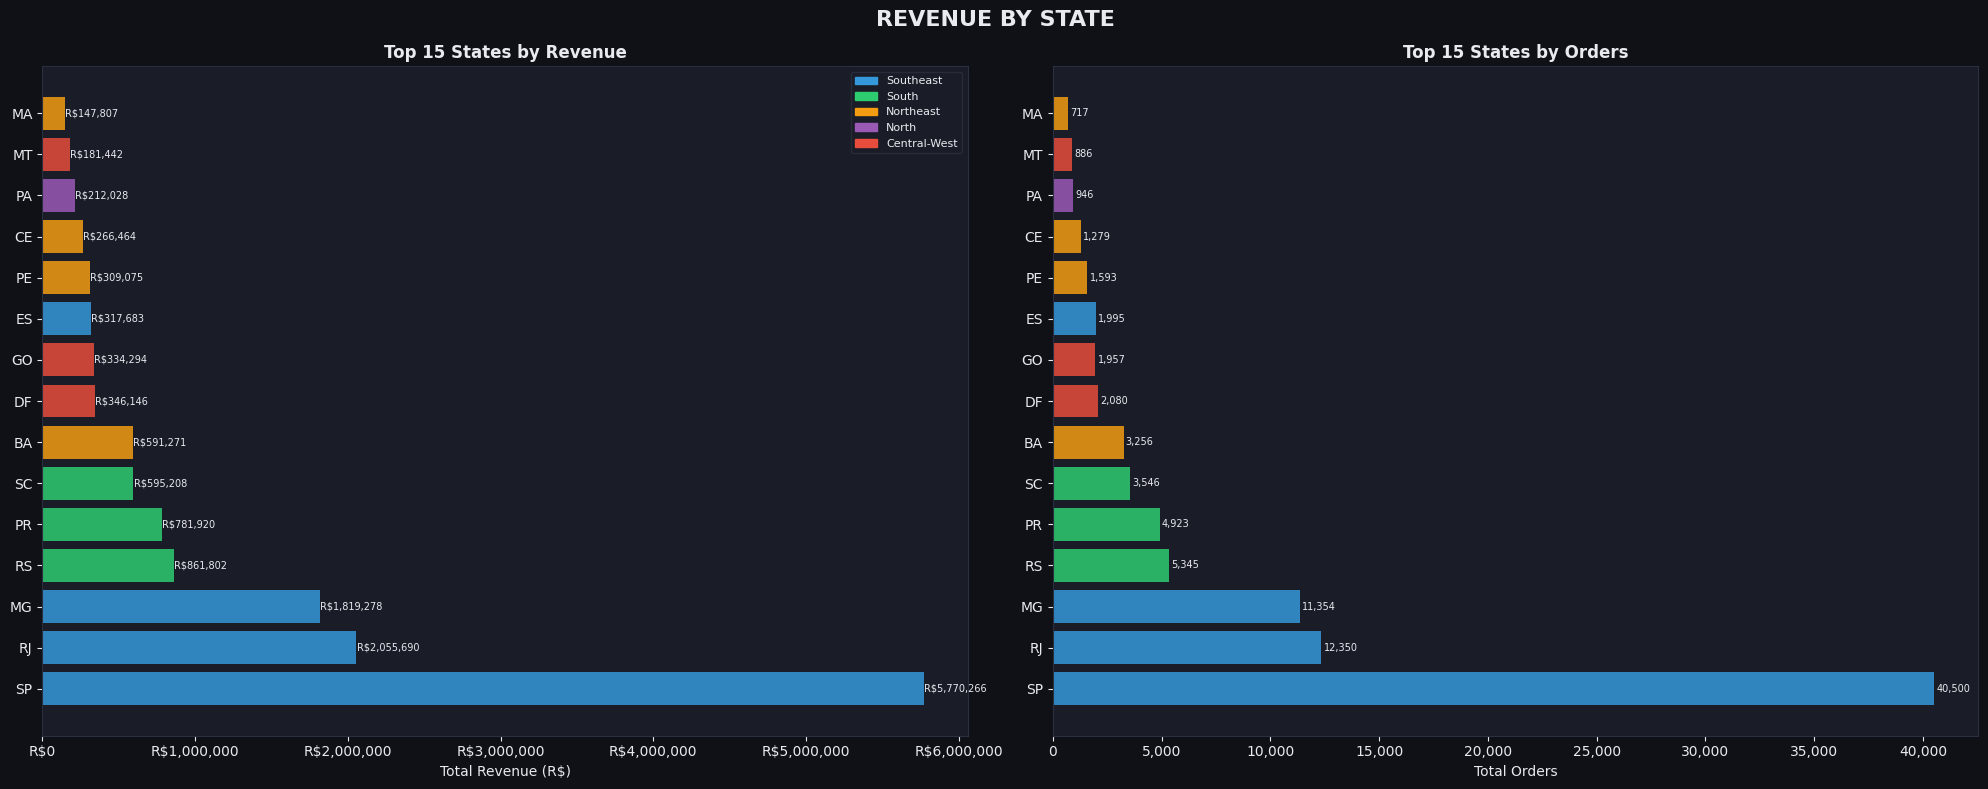

In [7]:
# Revenue by State
df = get_revenue_by_state().head(15)

fig, axes = plt.subplots(1, 2, figsize=(20, 8), facecolor=BG)
fig.suptitle(
    "REVENUE BY STATE",
    fontsize=16, fontweight="bold", color=TEXT_C
)

region_colors = {
    "Southeast"   : BLUE,
    "South"       : GREEN,
    "Northeast"   : ORANGE,
    "North"       : PURPLE,
    "Central-West": RED,
}
colors = [
    region_colors.get(r, BLUE)
    for r in df["region"]
]

# Plot 1: Revenue by state
ax = axes[0]
bars = ax.barh(
    df["state"], df["total_revenue"],
    color=colors, edgecolor="none", alpha=0.85
)
ax.set_xlabel("Total Revenue (R$)")
ax.set_title("Top 15 States by Revenue")
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f"R${x:,.0f}")
)
for bar, val in zip(bars, df["total_revenue"]):
    ax.text(
        val + 1000,
        bar.get_y() + bar.get_height() / 2,
        f"R${val:,.0f}",
        va="center", fontsize=7, color=TEXT_C
    )

# Region legend
handles = [
    plt.Rectangle((0, 0), 1, 1, color=c)
    for c in region_colors.values()
]
ax.legend(
    handles, region_colors.keys(),
    facecolor=CARD_BG, labelcolor=TEXT_C,
    edgecolor=GRID_C, fontsize=8
)

# Plot 2: Orders by state
ax = axes[1]
bars2 = ax.barh(
    df["state"], df["total_orders"],
    color=colors, edgecolor="none", alpha=0.85
)
ax.set_xlabel("Total Orders")
ax.set_title("Top 15 States by Orders")
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f"{x:,.0f}")
)
for bar, val in zip(bars2, df["total_orders"]):
    ax.text(
        val + 100,
        bar.get_y() + bar.get_height() / 2,
        f"{val:,}",
        va="center", fontsize=7, color=TEXT_C
    )

plt.tight_layout()
plt.show()

2026-05-23 10:19:07 | INFO     | src.sql_queries | [OK] Q6: Customer segmentation fetched


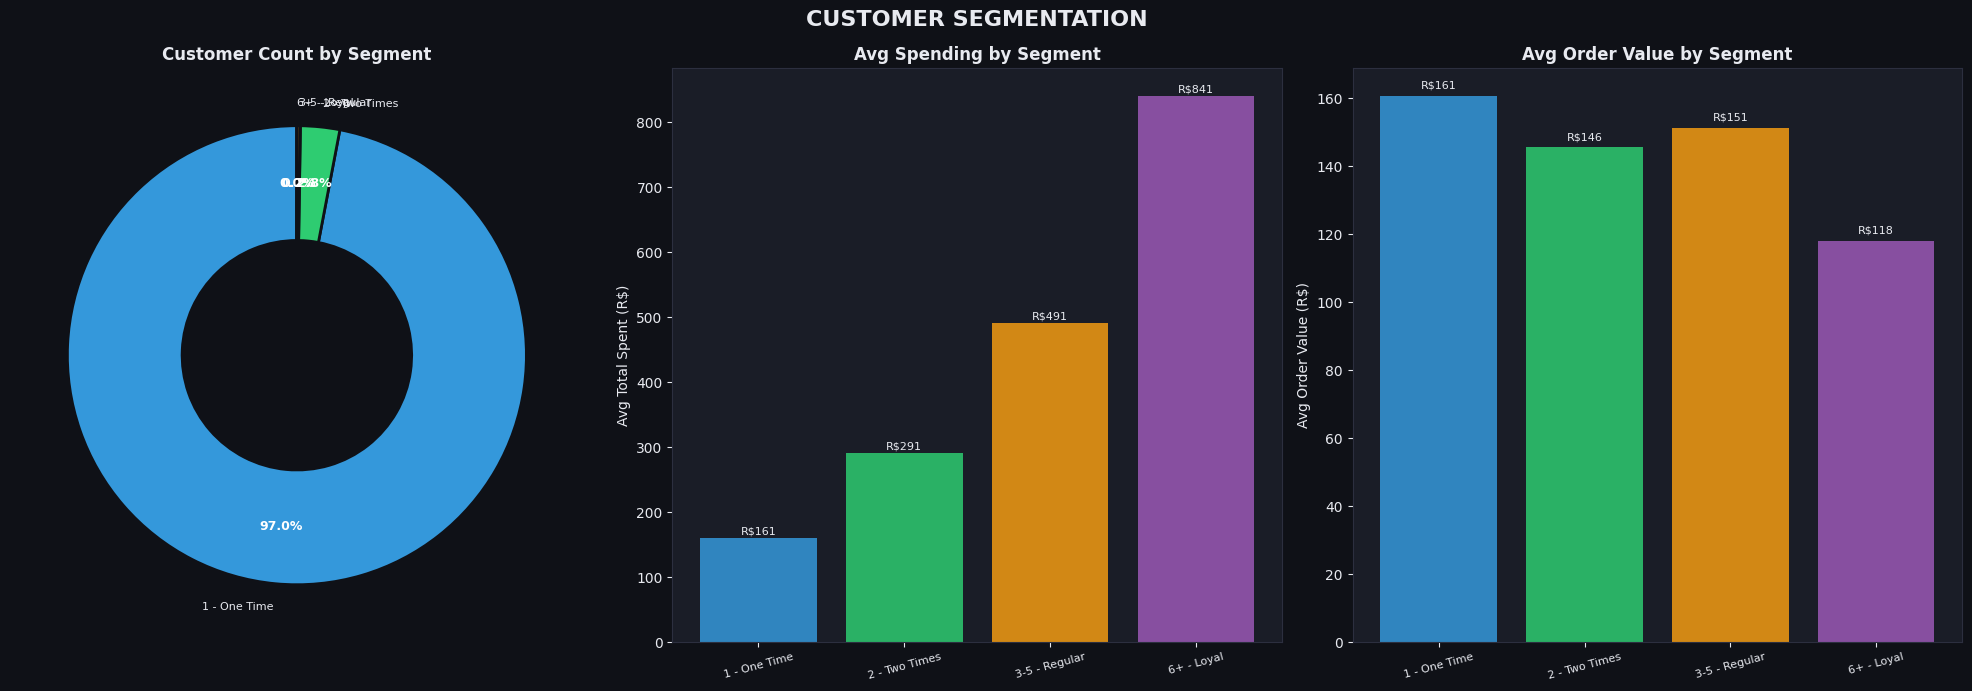

In [8]:
# Customer Segmentation
df = get_customer_segmentation()

fig, axes = plt.subplots(1, 3, figsize=(20, 7), facecolor=BG)
fig.suptitle(
    "CUSTOMER SEGMENTATION",
    fontsize=16, fontweight="bold", color=TEXT_C
)

colors = [BLUE, GREEN, ORANGE, PURPLE]

# Plot 1: Customer count donut
ax = axes[0]
wedges, texts, autotexts = ax.pie(
    df["customer_count"],
    labels=df["customer_segment"],
    autopct="%1.1f%%",
    colors=colors,
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(
        width=0.5,
        edgecolor=BG,
        linewidth=2
    )
)
for at in autotexts:
    at.set(fontsize=9, fontweight="bold", color="white")
for t in texts:
    t.set(fontsize=8, color=TEXT_C)
ax.set_title("Customer Count by Segment")

# Plot 2: Avg total spent
ax = axes[1]
bars = ax.bar(
    df["customer_segment"],
    df["avg_total_spent"],
    color=colors, edgecolor="none", alpha=0.85
)
ax.set_ylabel("Avg Total Spent (R$)")
ax.set_title("Avg Spending by Segment")
ax.tick_params(axis="x", rotation=15, labelsize=8)
for bar, val in zip(bars, df["avg_total_spent"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + 5,
        f"R${val:,.0f}",
        ha="center", fontsize=8, color=TEXT_C
    )

# Plot 3: Avg order value
ax = axes[2]
bars = ax.bar(
    df["customer_segment"],
    df["avg_order_value"],
    color=colors, edgecolor="none", alpha=0.85
)
ax.set_ylabel("Avg Order Value (R$)")
ax.set_title("Avg Order Value by Segment")
ax.tick_params(axis="x", rotation=15, labelsize=8)
for bar, val in zip(bars, df["avg_order_value"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + 2,
        f"R${val:,.0f}",
        ha="center", fontsize=8, color=TEXT_C
    )

plt.tight_layout()
plt.show()

2026-05-23 10:23:26 | INFO     | src.sql_queries | [OK] Q13: Order status fetched


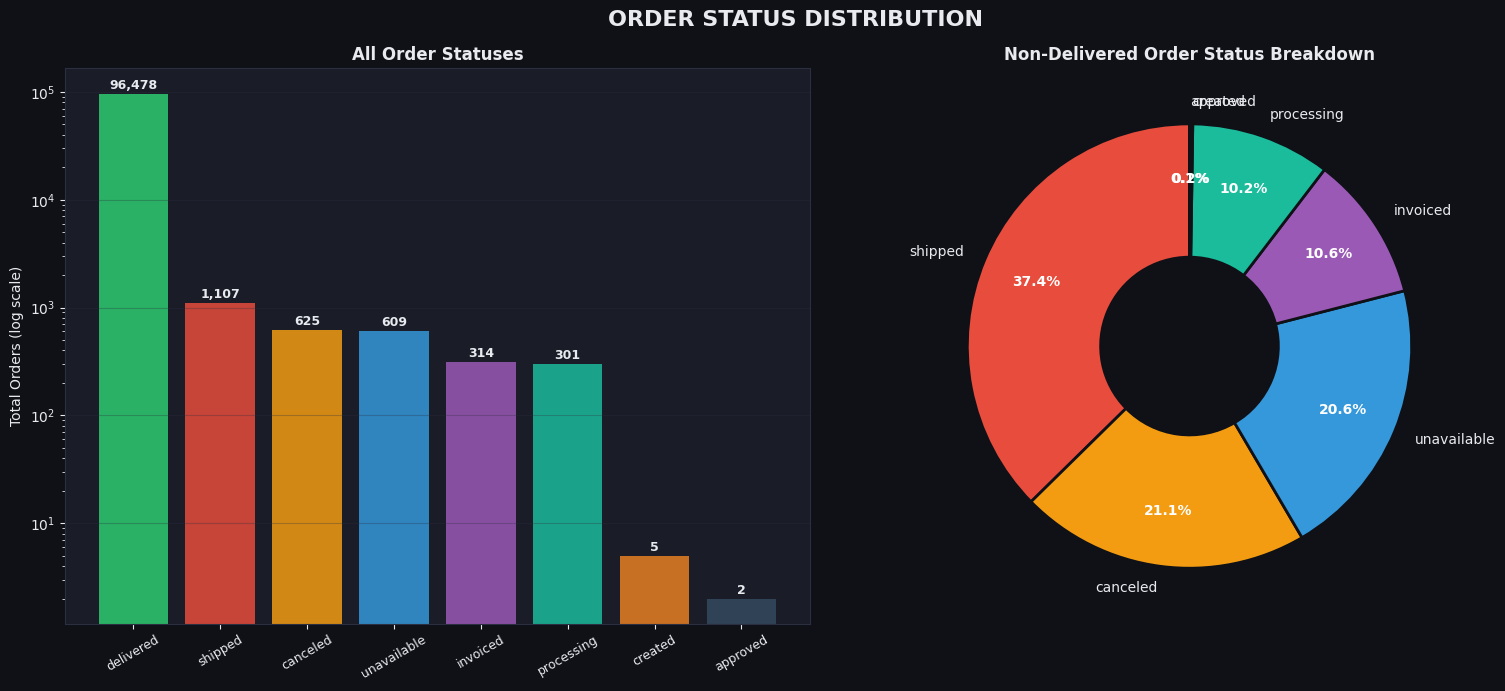

In [12]:
# Order Status Distribution
df = get_order_status_summary()

fig, axes = plt.subplots(1, 2, figsize=(16, 7), facecolor=BG)
fig.suptitle(
    "ORDER STATUS DISTRIBUTION",
    fontsize=16, fontweight="bold", color=TEXT_C
)

colors = [GREEN, RED, ORANGE, BLUE, PURPLE,
          "#1ABC9C", "#E67E22", "#34495E"]

# Plot 1: All statuses log scale bar
ax = axes[0]
bars = ax.bar(
    df["order_status"], df["total_orders"],
    color=colors[:len(df)], edgecolor="none", alpha=0.85
)
ax.set_ylabel("Total Orders (log scale)")
ax.set_title("All Order Statuses")
ax.set_yscale("log")
ax.tick_params(axis="x", rotation=30, labelsize=9)
for bar, val in zip(bars, df["total_orders"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val * 1.1,
        f"{val:,}",
        ha="center", fontsize=9,
        fontweight="bold", color=TEXT_C
    )
ax.grid(axis="y", alpha=0.3)

# Plot 2: Exclude delivered to see minority statuses
df_excl = df[df["order_status"] != "delivered"].copy()
ax = axes[1]
wedges, texts, autotexts = ax.pie(
    df_excl["total_orders"],
    labels=df_excl["order_status"],
    autopct="%1.1f%%",
    colors=colors[1:len(df_excl)+1],
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(
        width=0.6,
        edgecolor=BG,
        linewidth=2
    )
)
for at in autotexts:
    at.set(fontsize=10, color="white", fontweight="bold")
for t in texts:
    t.set(fontsize=10, color=TEXT_C)
ax.set_title("Non-Delivered Order Status Breakdown")

plt.tight_layout()
plt.show()

2026-05-23 10:24:58 | INFO     | src.sql_queries | [OK] Q17: Payment analysis fetched


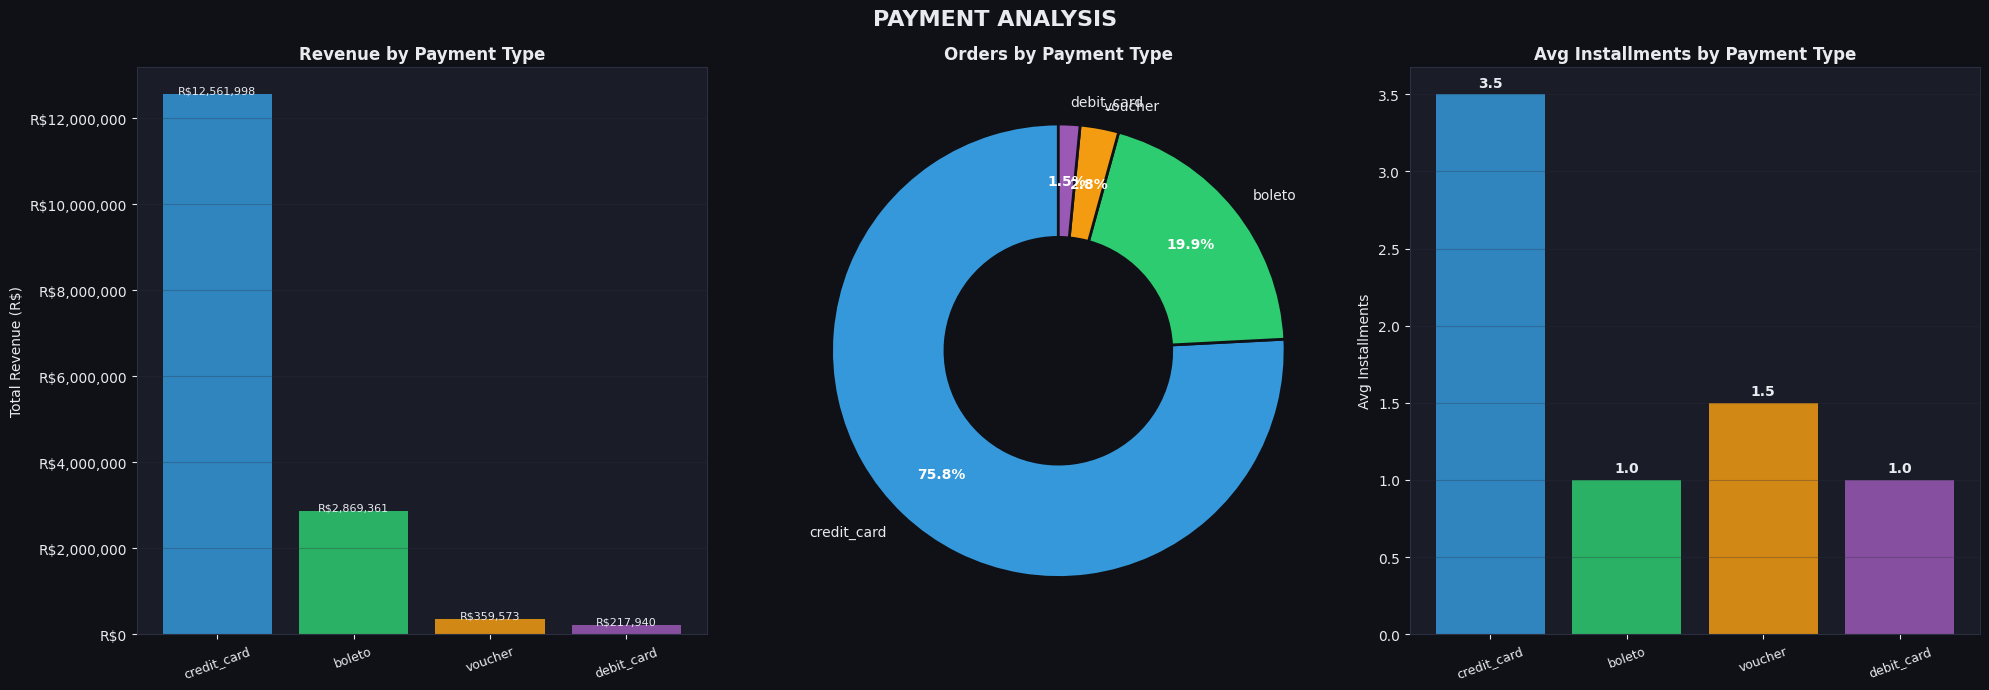

In [13]:
# Payment Analysis
df = get_payment_analysis()

fig, axes = plt.subplots(1, 3, figsize=(20, 7), facecolor=BG)
fig.suptitle(
    "PAYMENT ANALYSIS",
    fontsize=16, fontweight="bold", color=TEXT_C
)

colors = [BLUE, GREEN, ORANGE, PURPLE]

# Plot 1: Revenue by payment type
ax = axes[0]
bars = ax.bar(
    df["payment_type"], df["total_revenue"],
    color=colors[:len(df)], edgecolor="none", alpha=0.85
)
ax.set_ylabel("Total Revenue (R$)")
ax.set_title("Revenue by Payment Type")
ax.tick_params(axis="x", rotation=20, labelsize=9)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f"R${x:,.0f}")
)
ax.grid(axis="y", alpha=0.3)
for bar, val in zip(bars, df["total_revenue"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + 10000,
        f"R${val:,.0f}",
        ha="center", fontsize=8, color=TEXT_C
    )

# Plot 2: Orders share donut
ax = axes[1]
wedges, texts, autotexts = ax.pie(
    df["total_orders"],
    labels=df["payment_type"],
    autopct="%1.1f%%",
    colors=colors[:len(df)],
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(
        width=0.5,
        edgecolor=BG,
        linewidth=2
    )
)
for at in autotexts:
    at.set(fontsize=10, fontweight="bold", color="white")
for t in texts:
    t.set(fontsize=10, color=TEXT_C)
ax.set_title("Orders by Payment Type")

# Plot 3: Avg installments
ax = axes[2]
bars = ax.bar(
    df["payment_type"], df["avg_installments"],
    color=colors[:len(df)], edgecolor="none", alpha=0.85
)
ax.set_ylabel("Avg Installments")
ax.set_title("Avg Installments by Payment Type")
ax.tick_params(axis="x", rotation=20, labelsize=9)
ax.grid(axis="y", alpha=0.3)
for bar, val in zip(bars, df["avg_installments"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.05,
        f"{val:.1f}",
        ha="center", fontsize=10,
        fontweight="bold", color=TEXT_C
    )

plt.tight_layout()
plt.show()

2026-05-23 10:27:08 | INFO     | src.sql_queries | [OK] Q19: Review analysis fetched


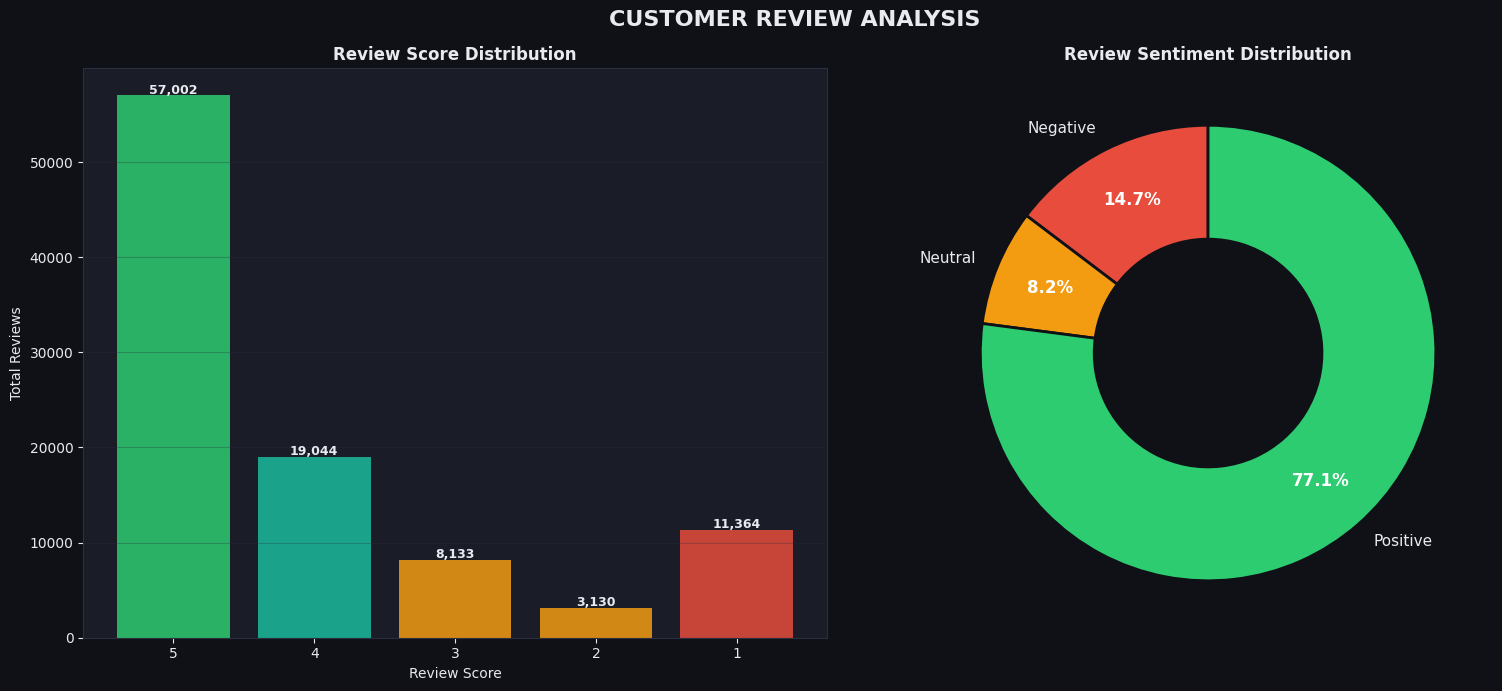

In [14]:
# Review Analysis
df = get_review_analysis()

fig, axes = plt.subplots(1, 2, figsize=(16, 7), facecolor=BG)
fig.suptitle(
    "CUSTOMER REVIEW ANALYSIS",
    fontsize=16, fontweight="bold", color=TEXT_C
)

score_colors = {
    1: RED,
    2: ORANGE,
    3: "#F39C12",
    4: "#1ABC9C",
    5: GREEN,
}
colors = [
    score_colors.get(s, BLUE)
    for s in df["review_score"]
]

# Plot 1: Review score distribution
ax = axes[0]
bars = ax.bar(
    df["review_score"].astype(str),
    df["total_reviews"],
    color=colors, edgecolor="none", alpha=0.85
)
ax.set_xlabel("Review Score")
ax.set_ylabel("Total Reviews")
ax.set_title("Review Score Distribution")
ax.grid(axis="y", alpha=0.3)
for bar, val in zip(bars, df["total_reviews"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + 200,
        f"{val:,}",
        ha="center", fontsize=9,
        fontweight="bold", color=TEXT_C
    )

# Plot 2: Sentiment donut
ax = axes[1]
sentiment = df.groupby(
    "review_sentiment"
)["total_reviews"].sum().reset_index()

sent_colors = {
    "Positive": GREEN,
    "Neutral" : ORANGE,
    "Negative": RED,
}
s_colors = [
    sent_colors.get(s, BLUE)
    for s in sentiment["review_sentiment"]
]
wedges, texts, autotexts = ax.pie(
    sentiment["total_reviews"],
    labels=sentiment["review_sentiment"],
    autopct="%1.1f%%",
    colors=s_colors,
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(
        width=0.5,
        edgecolor=BG,
        linewidth=2
    )
)
for at in autotexts:
    at.set(fontsize=12, fontweight="bold", color="white")
for t in texts:
    t.set(fontsize=11, color=TEXT_C)
ax.set_title("Review Sentiment Distribution")

plt.tight_layout()
plt.show()

2026-05-23 10:38:49 | INFO     | src.sql_queries | [OK] Q15: Orders by weekday fetched
2026-05-23 10:38:49 | INFO     | src.sql_queries | [OK] Q16: Orders by hour fetched


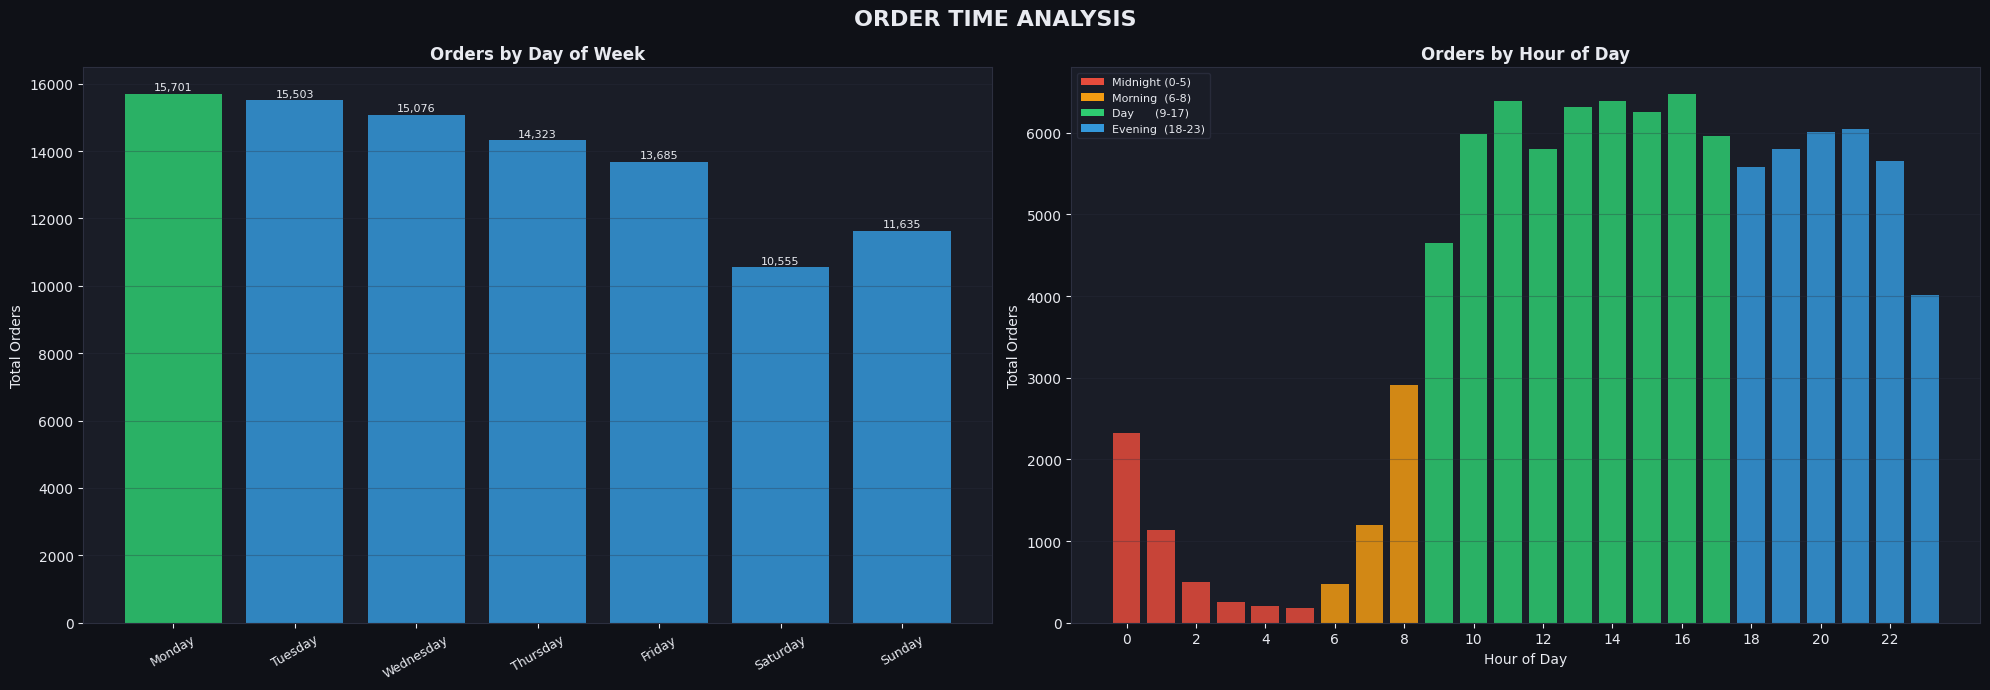

In [16]:
# Orders by Weekday and Hour
df_weekday = get_orders_by_weekday()
df_hour    = get_orders_by_hour()

fig, axes = plt.subplots(1, 2, figsize=(20, 7), facecolor=BG)
fig.suptitle(
    "ORDER TIME ANALYSIS",
    fontsize=16, fontweight="bold", color=TEXT_C
)

# Plot 1: Orders by weekday
ax = axes[0]
bar_colors = [
    GREEN if v == df_weekday["total_orders"].max()
    else BLUE
    for v in df_weekday["total_orders"]
]
bars = ax.bar(
    df_weekday["weekday"],
    df_weekday["total_orders"],
    color=bar_colors, edgecolor="none", alpha=0.85
)
ax.set_ylabel("Total Orders")
ax.set_title("Orders by Day of Week")
ax.tick_params(axis="x", rotation=30, labelsize=9)
ax.grid(axis="y", alpha=0.3)
for bar, val in zip(bars, df_weekday["total_orders"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + 100,
        f"{val:,}",
        ha="center", fontsize=8, color=TEXT_C
    )

# Plot 2: Orders by hour
ax = axes[1]
hour_colors = [
    RED    if h < 6
    else ORANGE if h < 9
    else GREEN  if h < 18
    else BLUE
    for h in df_hour["hour_of_day"]
]
bars = ax.bar(
    df_hour["hour_of_day"],
    df_hour["total_orders"],
    color=hour_colors, edgecolor="none", alpha=0.85
)
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Total Orders")
ax.set_title("Orders by Hour of Day")
ax.set_xticks(range(0, 24, 2))
ax.grid(axis="y", alpha=0.3)

# Add legend for hour colors
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=RED,    label="Midnight (0-5)"),
    Patch(facecolor=ORANGE, label="Morning  (6-8)"),
    Patch(facecolor=GREEN,  label="Day      (9-17)"),
    Patch(facecolor=BLUE,   label="Evening  (18-23)"),
]
ax.legend(
    handles=legend_elements,
    facecolor=CARD_BG, labelcolor=TEXT_C,
    edgecolor=GRID_C, fontsize=8
)

plt.tight_layout()
plt.show()

2026-05-23 10:39:39 | INFO     | src.sql_queries | [OK] Q14: Delivery analysis fetched


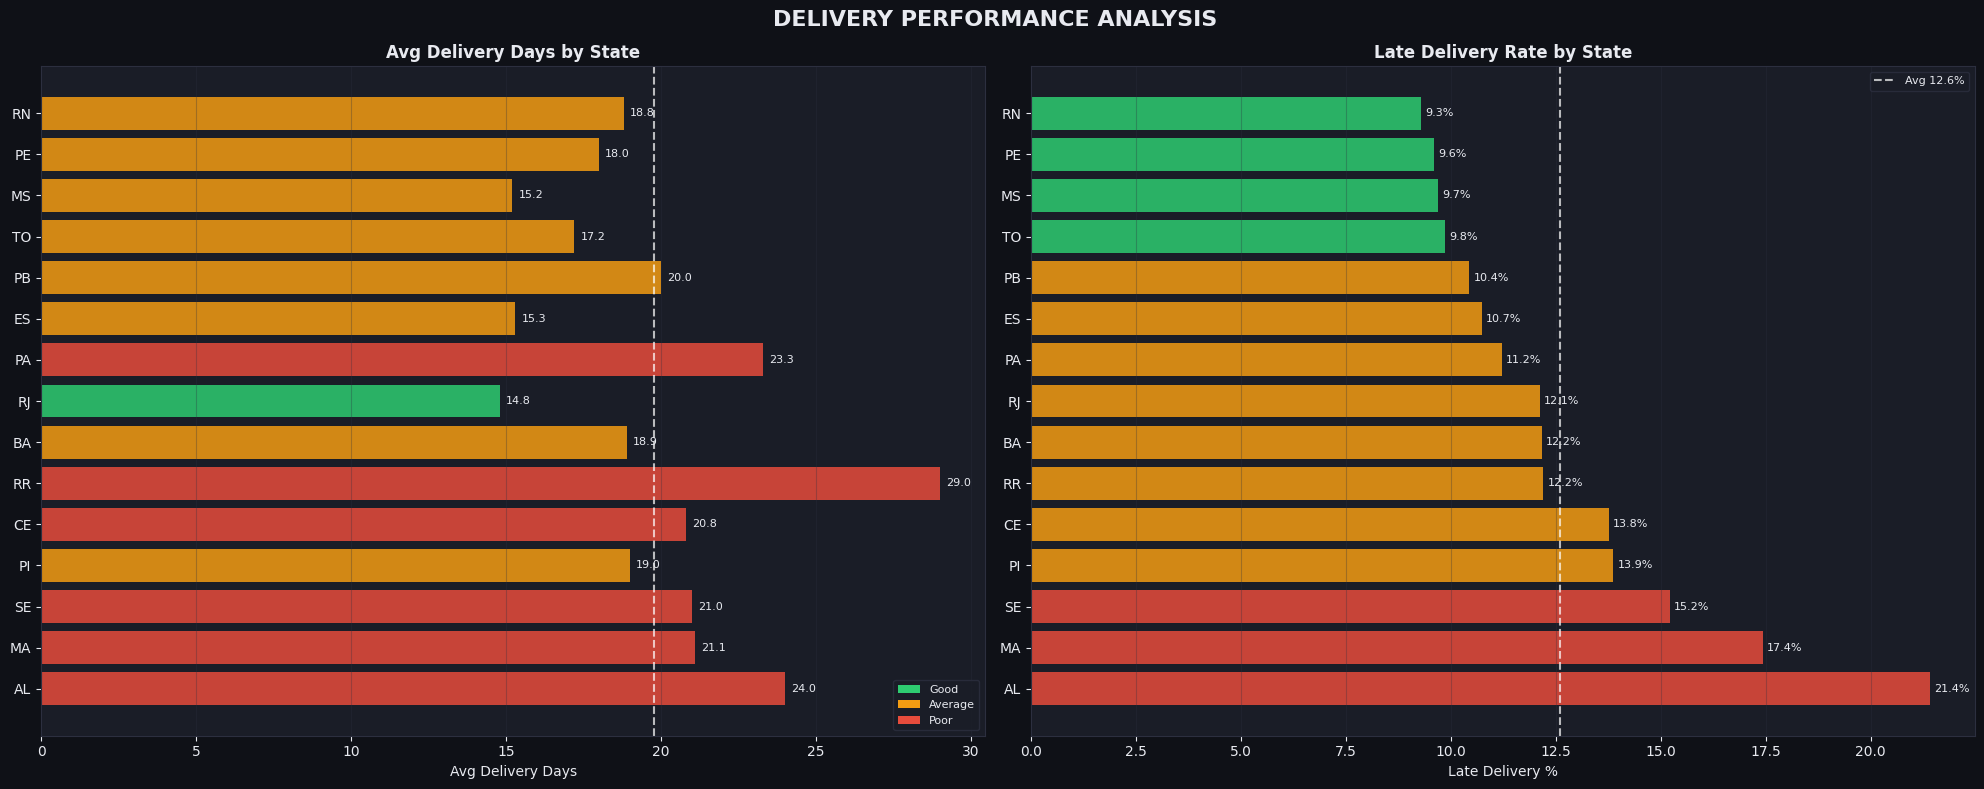

In [18]:
# Delivery Analysis
df = get_delivery_analysis().head(15)

fig, axes = plt.subplots(1, 2, figsize=(20, 8), facecolor=BG)
fig.suptitle(
    "DELIVERY PERFORMANCE ANALYSIS",
    fontsize=16, fontweight="bold", color=TEXT_C
)

# Plot 1: Avg delivery days by state
ax = axes[0]
colors1 = [
    RED    if v > 20
    else ORANGE if v > 15
    else GREEN
    for v in df["avg_delivery_days"]
]
bars = ax.barh(
    df["state"], df["avg_delivery_days"],
    color=colors1, edgecolor="none", alpha=0.85
)
ax.set_xlabel("Avg Delivery Days")
ax.set_title("Avg Delivery Days by State")
ax.axvline(
    df["avg_delivery_days"].mean(),
    color="white", lw=1.5, ls="--", alpha=0.7,
    label=f"Avg {df['avg_delivery_days'].mean():.1f} days"
)
ax.legend(
    facecolor=CARD_BG, labelcolor=TEXT_C,
    edgecolor=GRID_C, fontsize=8
)
ax.grid(axis="x", alpha=0.3)
for bar, val in zip(bars, df["avg_delivery_days"]):
    ax.text(
        val + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.1f}",
        va="center", fontsize=8, color=TEXT_C
    )

# Plot 2: Late delivery % by state
ax = axes[1]
colors2 = [
    RED    if v > 15
    else ORANGE if v > 10
    else GREEN
    for v in df["late_pct"]
]
bars2 = ax.barh(
    df["state"], df["late_pct"],
    color=colors2, edgecolor="none", alpha=0.85
)
ax.set_xlabel("Late Delivery %")
ax.set_title("Late Delivery Rate by State")
ax.axvline(
    df["late_pct"].mean(),
    color="white", lw=1.5, ls="--", alpha=0.7,
    label=f"Avg {df['late_pct'].mean():.1f}%"
)
ax.legend(
    facecolor=CARD_BG, labelcolor=TEXT_C,
    edgecolor=GRID_C, fontsize=8
)
ax.grid(axis="x", alpha=0.3)
for bar, val in zip(bars2, df["late_pct"]):
    ax.text(
        val + 0.1,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.1f}%",
        va="center", fontsize=8, color=TEXT_C
    )

# Add color legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=GREEN,  label="Good"),
    Patch(facecolor=ORANGE, label="Average"),
    Patch(facecolor=RED,    label="Poor"),
]
axes[0].legend(
    handles=legend_elements,
    facecolor=CARD_BG, labelcolor=TEXT_C,
    edgecolor=GRID_C, fontsize=8,
    loc="lower right"
)

plt.tight_layout()
plt.show()

2026-05-23 10:40:35 | INFO     | src.sql_queries | [OK] Q11: Seller performance fetched


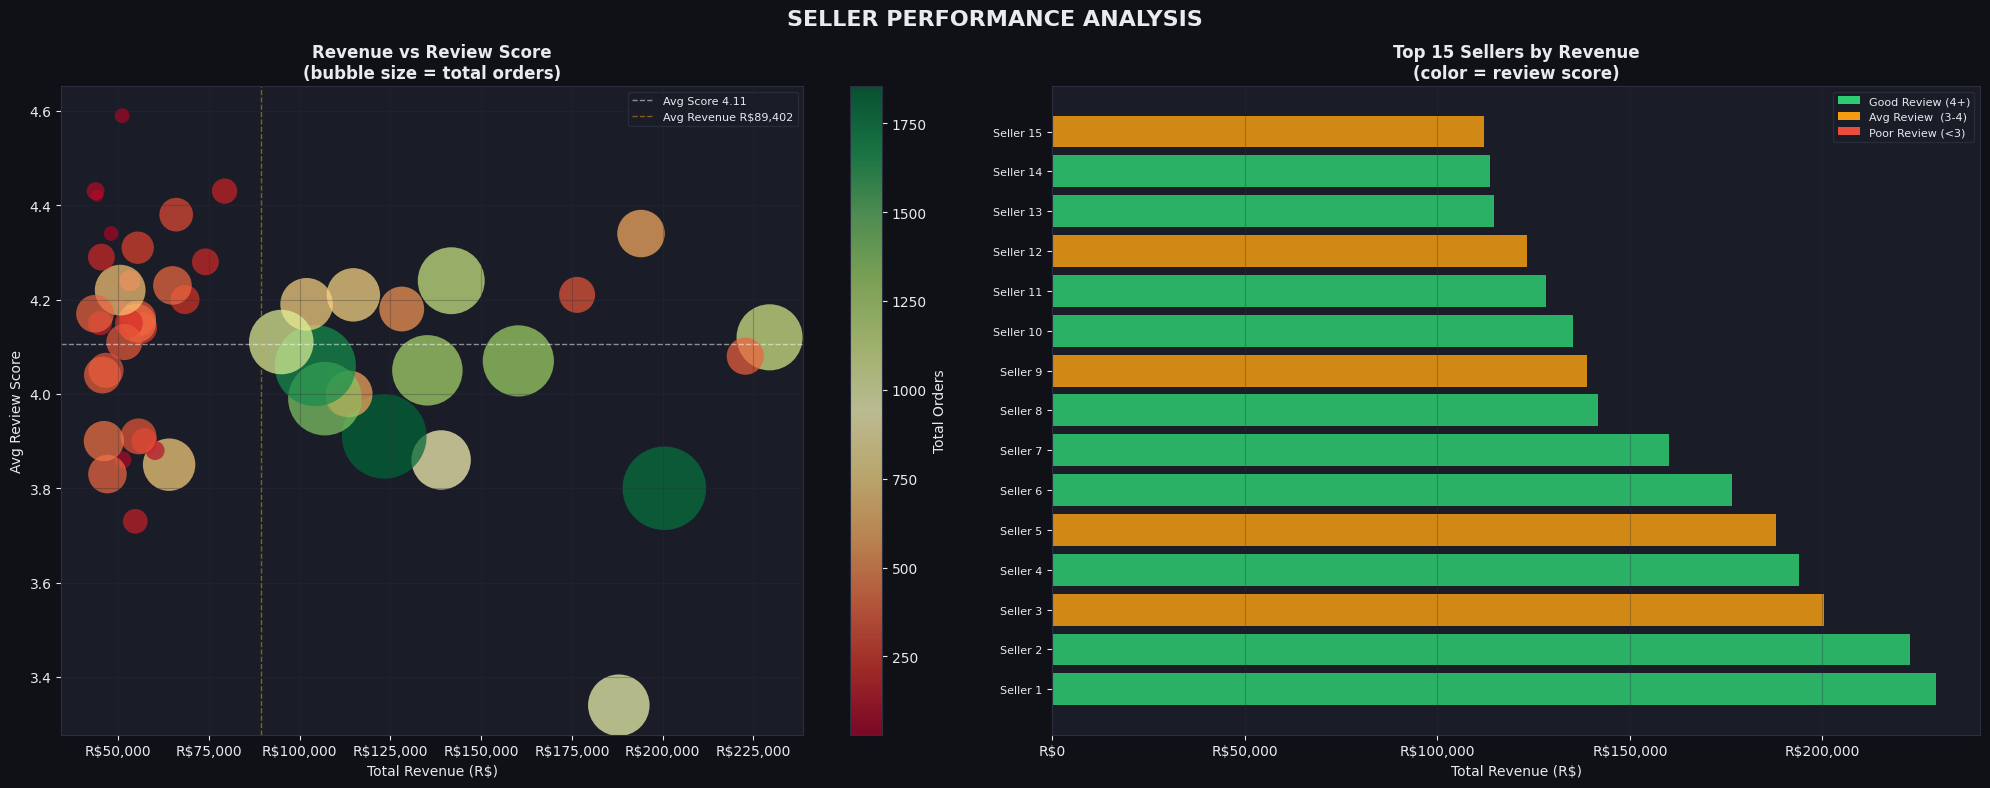

In [19]:
# Seller Performance
df = get_seller_performance().head(50)

fig, axes = plt.subplots(1, 2, figsize=(20, 8), facecolor=BG)
fig.suptitle(
    "SELLER PERFORMANCE ANALYSIS",
    fontsize=16, fontweight="bold", color=TEXT_C
)

# Plot 1: Revenue vs Review Score scatter
ax = axes[0]
scatter = ax.scatter(
    df["total_revenue"],
    df["avg_review_score"],
    c=df["total_orders"],
    cmap="RdYlGn",
    s=df["total_orders"] * 2,
    alpha=0.7,
    edgecolors="none"
)
plt.colorbar(scatter, ax=ax, label="Total Orders")
ax.set_xlabel("Total Revenue (R$)")
ax.set_ylabel("Avg Review Score")
ax.set_title("Revenue vs Review Score\n(bubble size = total orders)")
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f"R${x:,.0f}")
)
ax.grid(alpha=0.3)

# Add quadrant lines
ax.axhline(
    df["avg_review_score"].mean(),
    color="white", lw=1, ls="--", alpha=0.5,
    label=f"Avg Score {df['avg_review_score'].mean():.2f}"
)
ax.axvline(
    df["total_revenue"].mean(),
    color=ORANGE, lw=1, ls="--", alpha=0.5,
    label=f"Avg Revenue R${df['total_revenue'].mean():,.0f}"
)
ax.legend(
    facecolor=CARD_BG, labelcolor=TEXT_C,
    edgecolor=GRID_C, fontsize=8
)

# Plot 2: Top 15 sellers by revenue
ax = axes[1]
top15    = df.head(15)
colors15 = [
    GREEN  if v >= 4
    else ORANGE if v >= 3
    else RED
    for v in top15["avg_review_score"]
]
bars = ax.barh(
    range(len(top15)),
    top15["total_revenue"],
    color=colors15, edgecolor="none", alpha=0.85
)
ax.set_yticks(range(len(top15)))
ax.set_yticklabels(
    [f"Seller {i+1}" for i in range(len(top15))],
    fontsize=8
)
ax.set_xlabel("Total Revenue (R$)")
ax.set_title("Top 15 Sellers by Revenue\n(color = review score)")
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f"R${x:,.0f}")
)
ax.grid(axis="x", alpha=0.3)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=GREEN,  label="Good Review (4+)"),
    Patch(facecolor=ORANGE, label="Avg Review  (3-4)"),
    Patch(facecolor=RED,    label="Poor Review (<3)"),
]
ax.legend(
    handles=legend_elements,
    facecolor=CARD_BG, labelcolor=TEXT_C,
    edgecolor=GRID_C, fontsize=8
)

plt.tight_layout()
plt.show()

Looking for file at: d:\Retail_analytics\data\processed\master_dataset.csv
File exists: True
Columns found: ['price', 'freight_value', 'total_item_value', 'delivery_days', 'delivery_delay_days', 'review_score', 'total_payment_value', 'max_installments', 'payment_count', 'purchase_hour', 'purchase_month', 'is_late_delivery']


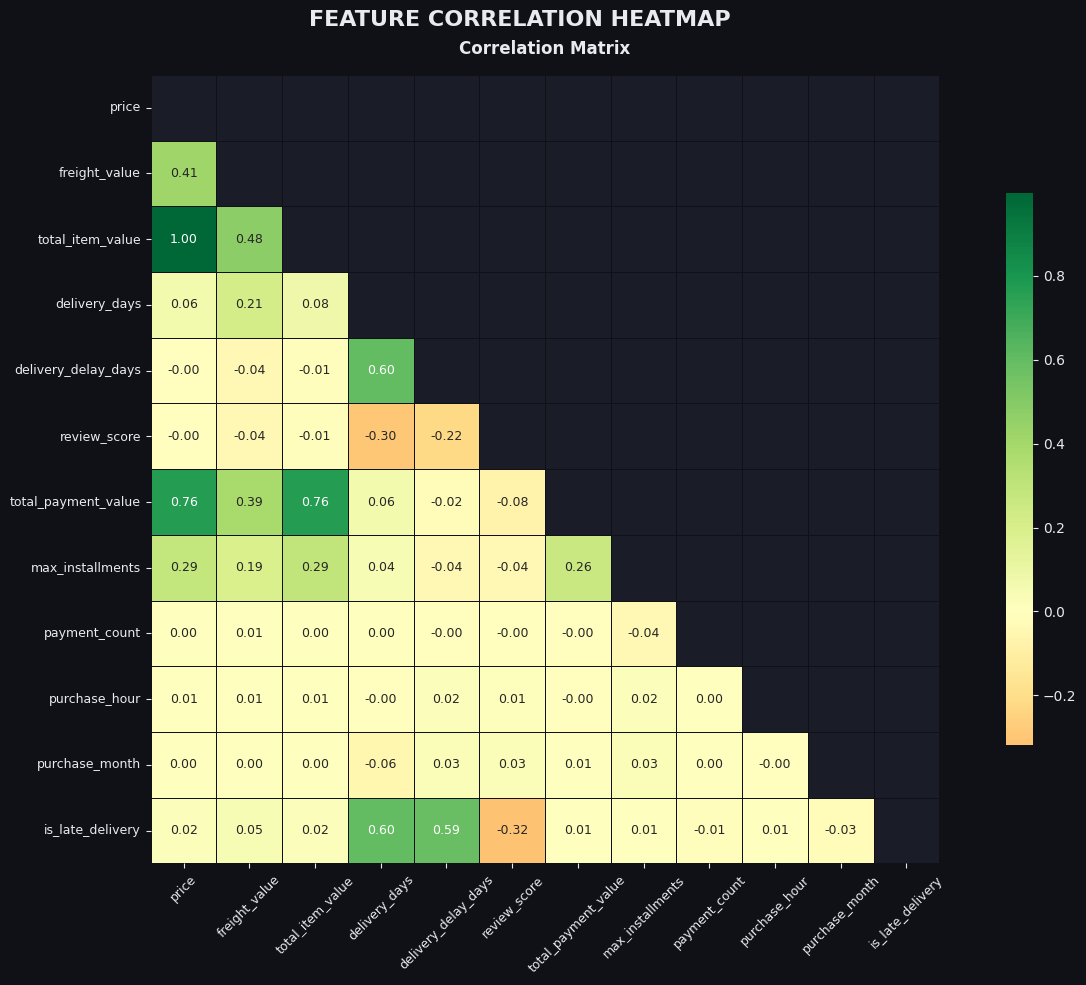

In [21]:
# Correlation Heatmap
import os
from pathlib import Path

# Fix path - go up one level from notebooks folder
BASE_DIR    = Path(os.getcwd()).parent
master_path = BASE_DIR / "data" / "processed" / "master_dataset.csv"

print("Looking for file at:", master_path)
print("File exists:", master_path.exists())

df = pd.read_csv(master_path)

# Select numeric columns
num_cols = [
    "price",
    "freight_value",
    "total_item_value",
    "delivery_days",
    "delivery_delay_days",
    "review_score",
    "total_payment_value",
    "max_installments",
    "payment_count",
    "purchase_hour",
    "purchase_month",
    "is_late_delivery",
]

# Keep only columns that exist
num_cols = [c for c in num_cols if c in df.columns]
print("Columns found:", num_cols)

corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10), facecolor=BG)
fig.suptitle(
    "FEATURE CORRELATION HEATMAP",
    fontsize=16, fontweight="bold", color=TEXT_C
)

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    ax=ax,
    mask=mask,
    cmap="RdYlGn",
    center=0,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 9},
    linewidths=0.5,
    linecolor=BG,
    square=True,
    cbar_kws={"shrink": 0.7}
)
ax.set_title(
    "Correlation Matrix",
    color=TEXT_C, pad=15
)
ax.tick_params(axis="x", rotation=45, labelsize=9)
ax.tick_params(axis="y", rotation=0,  labelsize=9)

plt.tight_layout()
plt.show()

2026-05-23 10:45:37 | INFO     | src.sql_queries | [OK] Q21: RFM segment summary fetched
          rfm_segment  customer_count  avg_monetary  total_monetary  \
0  Potential Loyalist           22008        300.52      6613771.37   
1                Lost           15336        306.80      4705110.91   
2     Loyal Customers           18609         87.18      1622350.24   
3             At Risk           22008         73.68      1621561.51   
4           Champions           15397         55.84       859667.74   

   avg_frequency  avg_recency_days  customer_pct  
0           1.08             366.5         23.57  
1           1.09             123.1         16.43  
2           1.00             320.8         19.93  
3           1.00             121.7         23.57  
4           1.00             428.0         16.49  


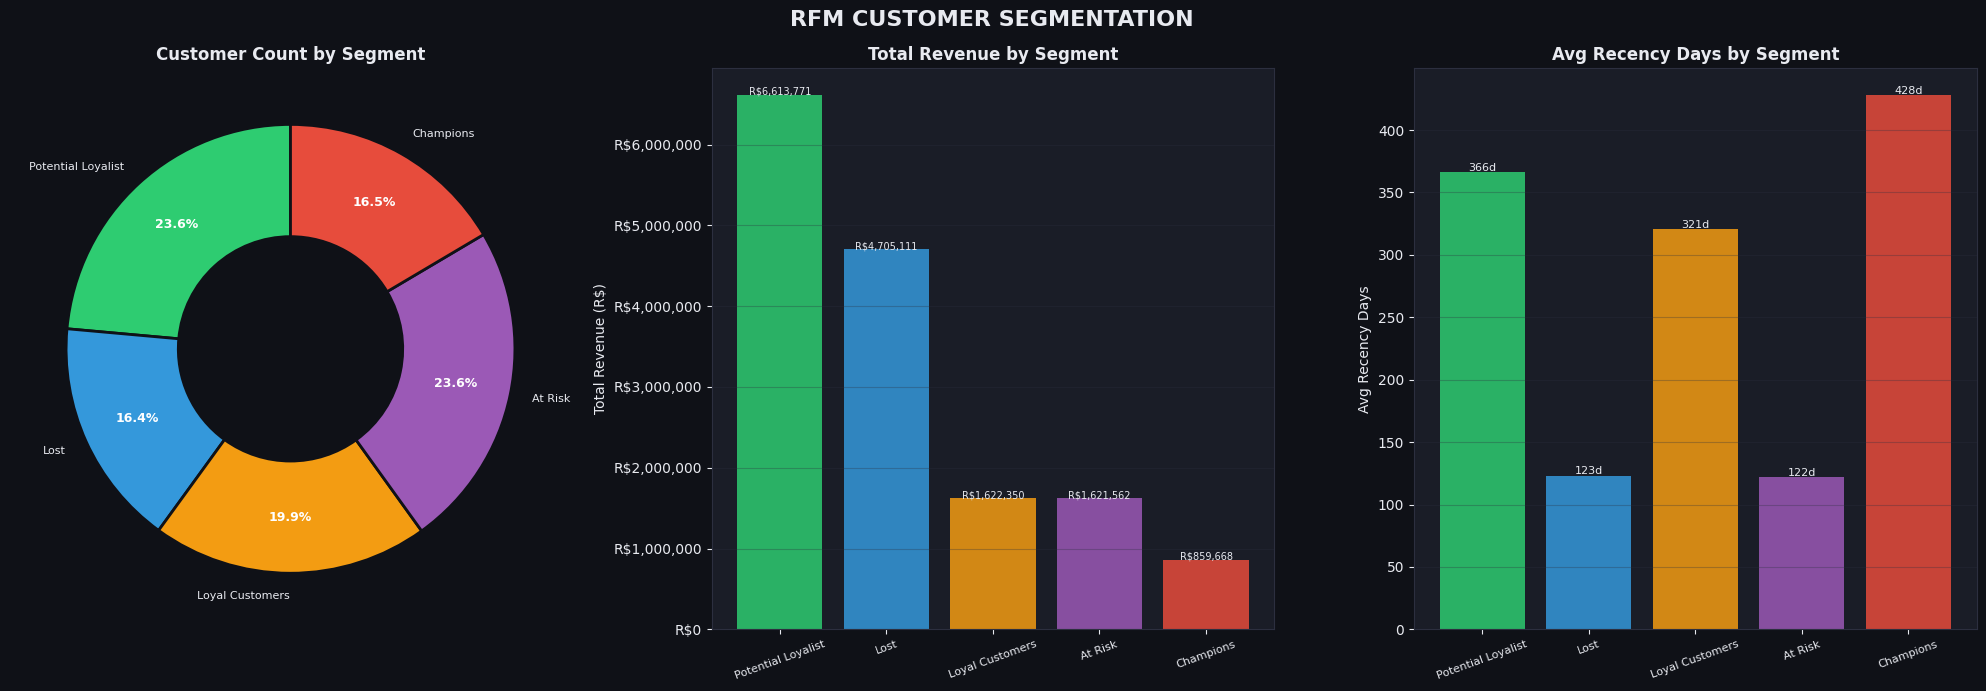

In [22]:
# RFM Segment Analysis
from src.sql_queries import get_rfm_segment_summary

df = get_rfm_segment_summary()
print(df)

fig, axes = plt.subplots(1, 3, figsize=(20, 7), facecolor=BG)
fig.suptitle(
    "RFM CUSTOMER SEGMENTATION",
    fontsize=16, fontweight="bold", color=TEXT_C
)

colors = [GREEN, BLUE, ORANGE, PURPLE, RED, "#1ABC9C"]

# Plot 1: Customer count by segment
ax = axes[0]
wedges, texts, autotexts = ax.pie(
    df["customer_count"],
    labels=df["rfm_segment"],
    autopct="%1.1f%%",
    colors=colors[:len(df)],
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(
        width=0.5,
        edgecolor=BG,
        linewidth=2
    )
)
for at in autotexts:
    at.set(fontsize=9, fontweight="bold", color="white")
for t in texts:
    t.set(fontsize=8, color=TEXT_C)
ax.set_title("Customer Count by Segment")

# Plot 2: Total monetary by segment
ax = axes[1]
bars = ax.bar(
    df["rfm_segment"], df["total_monetary"],
    color=colors[:len(df)], edgecolor="none", alpha=0.85
)
ax.set_ylabel("Total Revenue (R$)")
ax.set_title("Total Revenue by Segment")
ax.tick_params(axis="x", rotation=20, labelsize=8)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f"R${x:,.0f}")
)
ax.grid(axis="y", alpha=0.3)
for bar, val in zip(bars, df["total_monetary"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + 1000,
        f"R${val:,.0f}",
        ha="center", fontsize=7, color=TEXT_C
    )

# Plot 3: Avg recency days by segment
ax = axes[2]
bars = ax.bar(
    df["rfm_segment"], df["avg_recency_days"],
    color=colors[:len(df)], edgecolor="none", alpha=0.85
)
ax.set_ylabel("Avg Recency Days")
ax.set_title("Avg Recency Days by Segment")
ax.tick_params(axis="x", rotation=20, labelsize=8)
ax.grid(axis="y", alpha=0.3)
for bar, val in zip(bars, df["avg_recency_days"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + 1,
        f"{val:.0f}d",
        ha="center", fontsize=8, color=TEXT_C
    )

plt.tight_layout()
plt.show()

2026-05-23 10:46:40 | INFO     | src.sql_queries | [OK] Q22: Running total revenue fetched


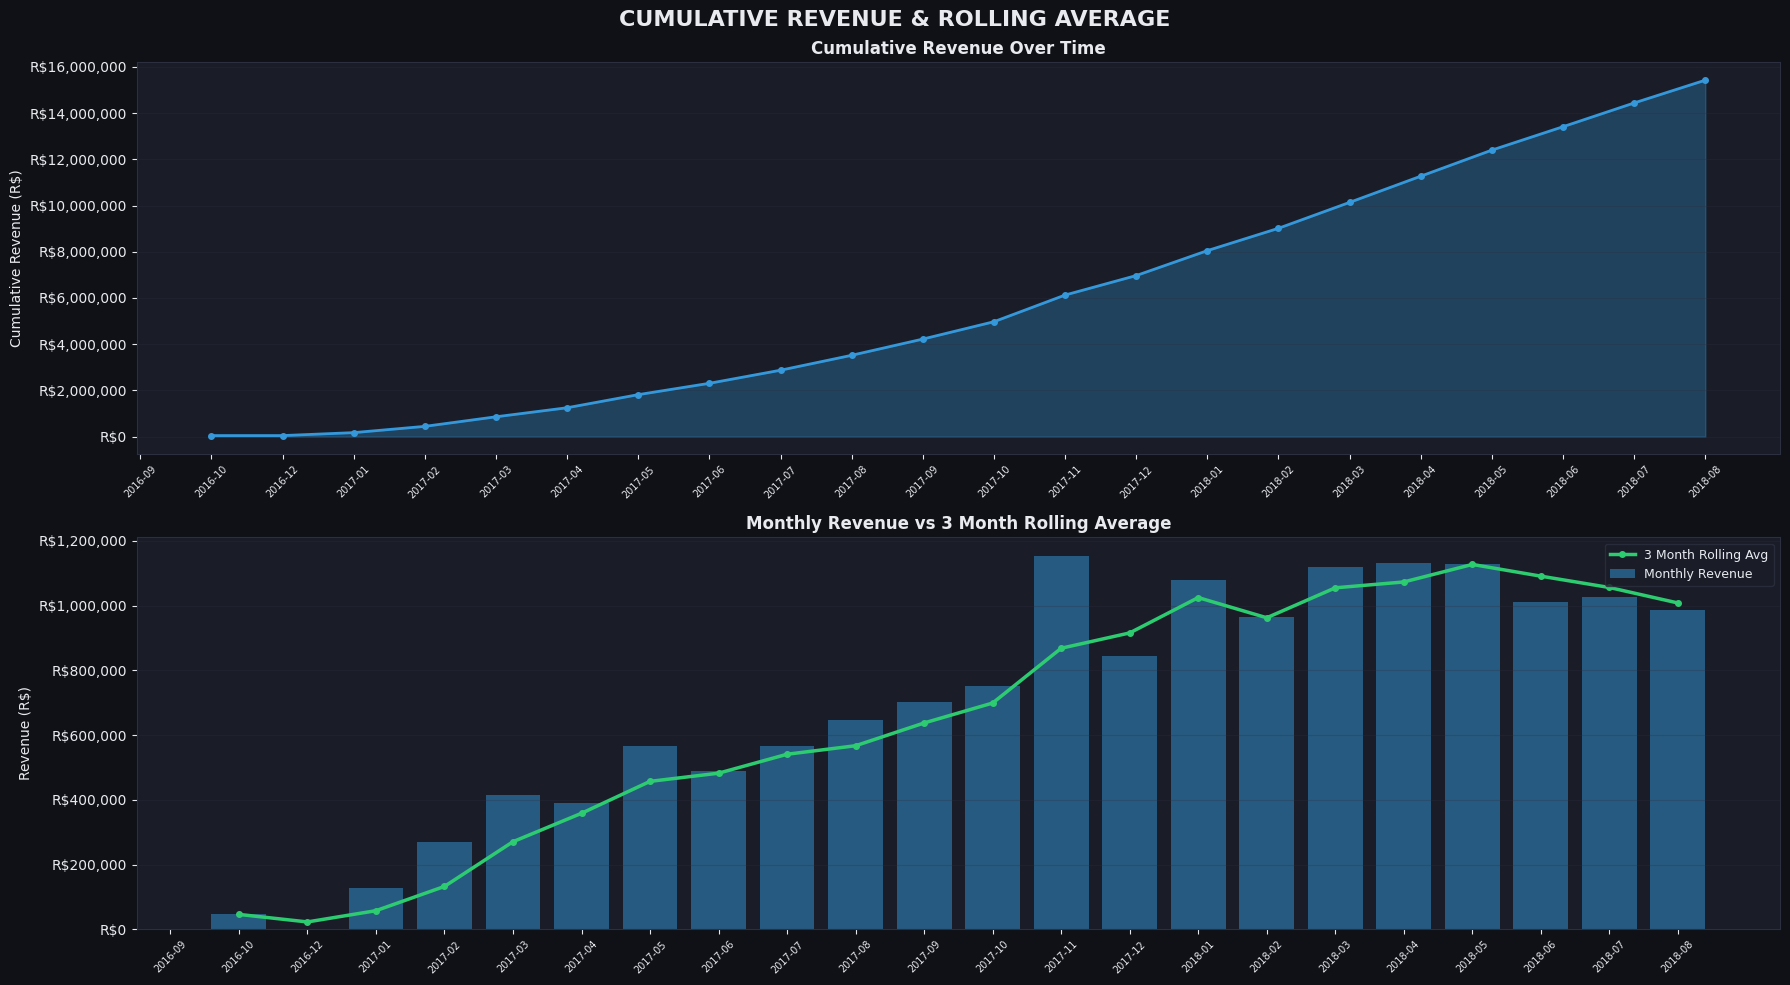

In [24]:
# Running Total Revenue & Rolling Average
from src.sql_queries import get_running_total_revenue

df = get_running_total_revenue()

fig, axes = plt.subplots(2, 1, figsize=(18, 10), facecolor=BG)
fig.suptitle(
    "CUMULATIVE REVENUE & ROLLING AVERAGE",
    fontsize=16, fontweight="bold", color=TEXT_C
)

# Plot 1: Cumulative revenue
ax = axes[0]
ax.fill_between(
    df["year_month"],
    df["cumulative_revenue"],
    alpha=0.3, color=BLUE
)
ax.plot(
    df["year_month"],
    df["cumulative_revenue"],
    color=BLUE, lw=2, marker="o", ms=4
)
ax.set_ylabel("Cumulative Revenue (R$)")
ax.set_title("Cumulative Revenue Over Time")
ax.tick_params(axis="x", rotation=45, labelsize=7)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f"R${x:,.0f}")
)
ax.grid(axis="y", alpha=0.3)

# Plot 2: Monthly vs Rolling 3 month avg
ax = axes[1]
ax.bar(
    df["year_month"],
    df["monthly_revenue"],
    color=BLUE, alpha=0.5,
    edgecolor="none", label="Monthly Revenue"
)
ax.plot(
    df["year_month"],
    df["rolling_3m_avg"],
    color=GREEN, lw=2.5,
    marker="o", ms=4,
    label="3 Month Rolling Avg"
)
ax.set_ylabel("Revenue (R$)")
ax.set_title("Monthly Revenue vs 3 Month Rolling Average")
ax.tick_params(axis="x", rotation=45, labelsize=7)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f"R${x:,.0f}")
)
ax.legend(
    facecolor=CARD_BG, labelcolor=TEXT_C,
    edgecolor=GRID_C, fontsize=9
)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

2026-05-23 10:47:36 | INFO     | src.sql_queries | [OK] Q23: Seller ranking fetched


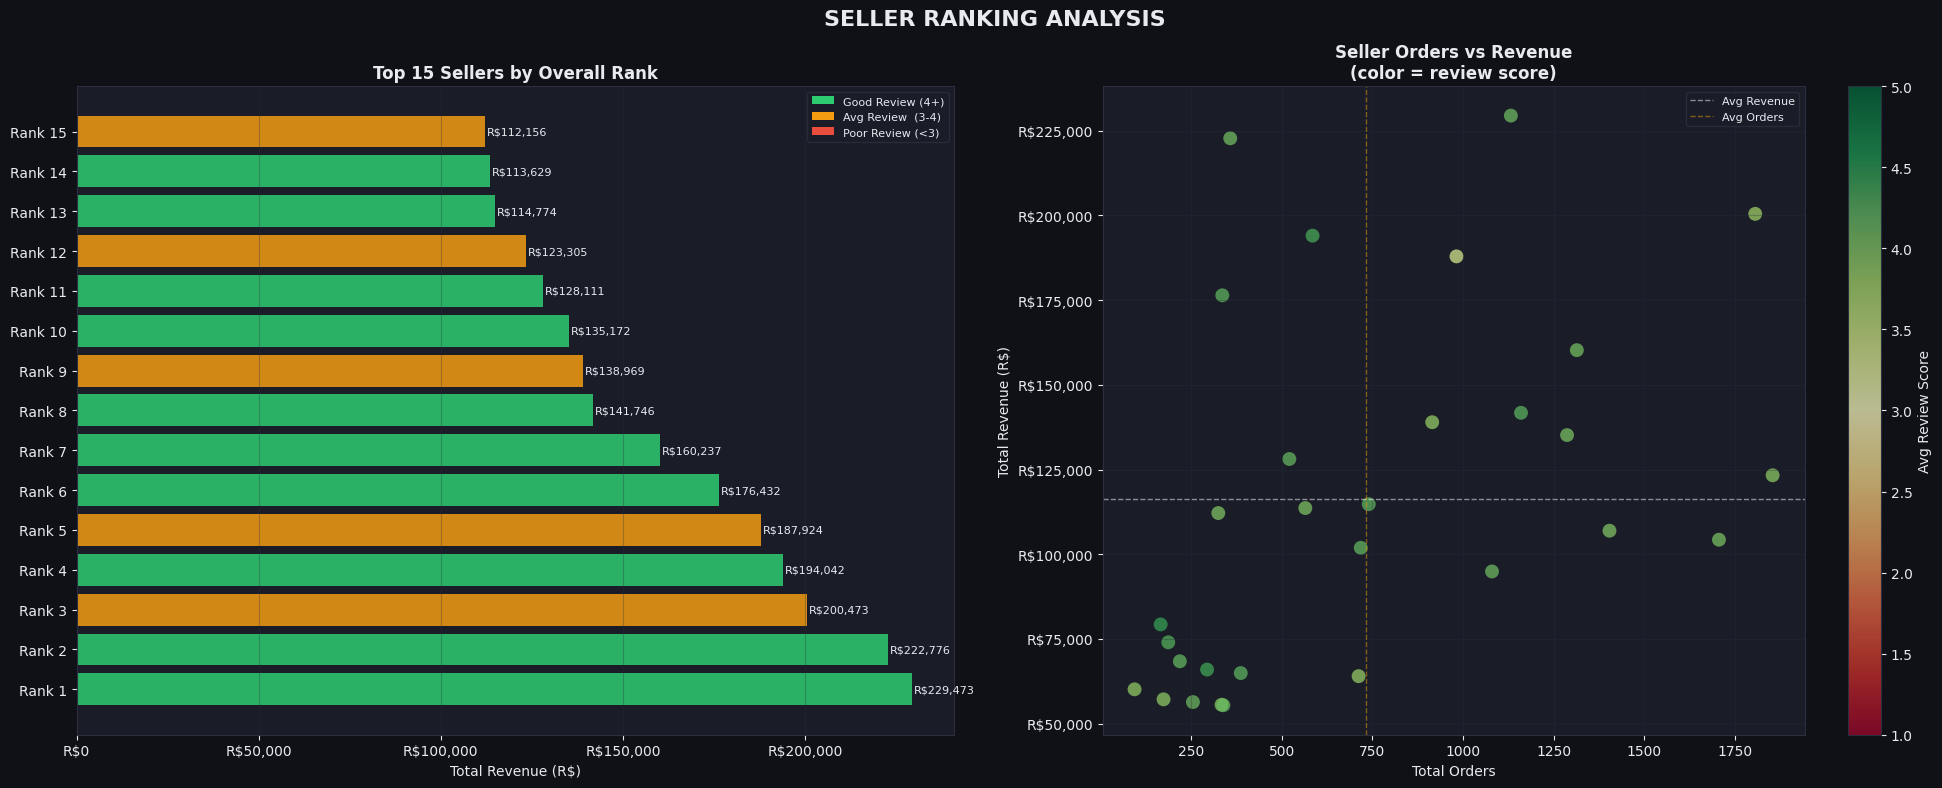

In [25]:
# Seller Ranking
from src.sql_queries import get_seller_ranking

df = get_seller_ranking()

fig, axes = plt.subplots(1, 2, figsize=(20, 8), facecolor=BG)
fig.suptitle(
    "SELLER RANKING ANALYSIS",
    fontsize=16, fontweight="bold", color=TEXT_C
)

# Plot 1: Top 15 sellers by revenue
ax = axes[0]
top15  = df.head(15)
colors = [
    GREEN  if v >= 4
    else ORANGE if v >= 3
    else RED
    for v in top15["avg_review_score"].fillna(0)
]
bars = ax.barh(
    [f"Rank {r}" for r in top15["overall_rank"]],
    top15["total_revenue"],
    color=colors, edgecolor="none", alpha=0.85
)
ax.set_xlabel("Total Revenue (R$)")
ax.set_title("Top 15 Sellers by Overall Rank")
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f"R${x:,.0f}")
)
ax.grid(axis="x", alpha=0.3)
for bar, val in zip(bars, top15["total_revenue"]):
    ax.text(
        val + 500,
        bar.get_y() + bar.get_height() / 2,
        f"R${val:,.0f}",
        va="center", fontsize=8, color=TEXT_C
    )

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=GREEN,  label="Good Review (4+)"),
    Patch(facecolor=ORANGE, label="Avg Review  (3-4)"),
    Patch(facecolor=RED,    label="Poor Review (<3)"),
]
ax.legend(
    handles=legend_elements,
    facecolor=CARD_BG, labelcolor=TEXT_C,
    edgecolor=GRID_C, fontsize=8
)

# Plot 2: Revenue vs orders scatter
ax = axes[1]
scatter = ax.scatter(
    df["total_orders"],
    df["total_revenue"],
    c=df["avg_review_score"].fillna(0),
    cmap="RdYlGn",
    s=100,
    alpha=0.7,
    edgecolors="none",
    vmin=1, vmax=5
)
plt.colorbar(
    scatter, ax=ax,
    label="Avg Review Score"
)
ax.set_xlabel("Total Orders")
ax.set_ylabel("Total Revenue (R$)")
ax.set_title("Seller Orders vs Revenue\n(color = review score)")
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f"R${x:,.0f}")
)
ax.grid(alpha=0.3)

# Quadrant lines
ax.axhline(
    df["total_revenue"].mean(),
    color="white", lw=1, ls="--",
    alpha=0.5, label="Avg Revenue"
)
ax.axvline(
    df["total_orders"].mean(),
    color=ORANGE, lw=1, ls="--",
    alpha=0.5, label="Avg Orders"
)
ax.legend(
    facecolor=CARD_BG, labelcolor=TEXT_C,
    edgecolor=GRID_C, fontsize=8
)

plt.tight_layout()
plt.show()

2026-05-23 10:50:00 | INFO     | src.sql_queries | [OK] Q24: Cohort data fetched


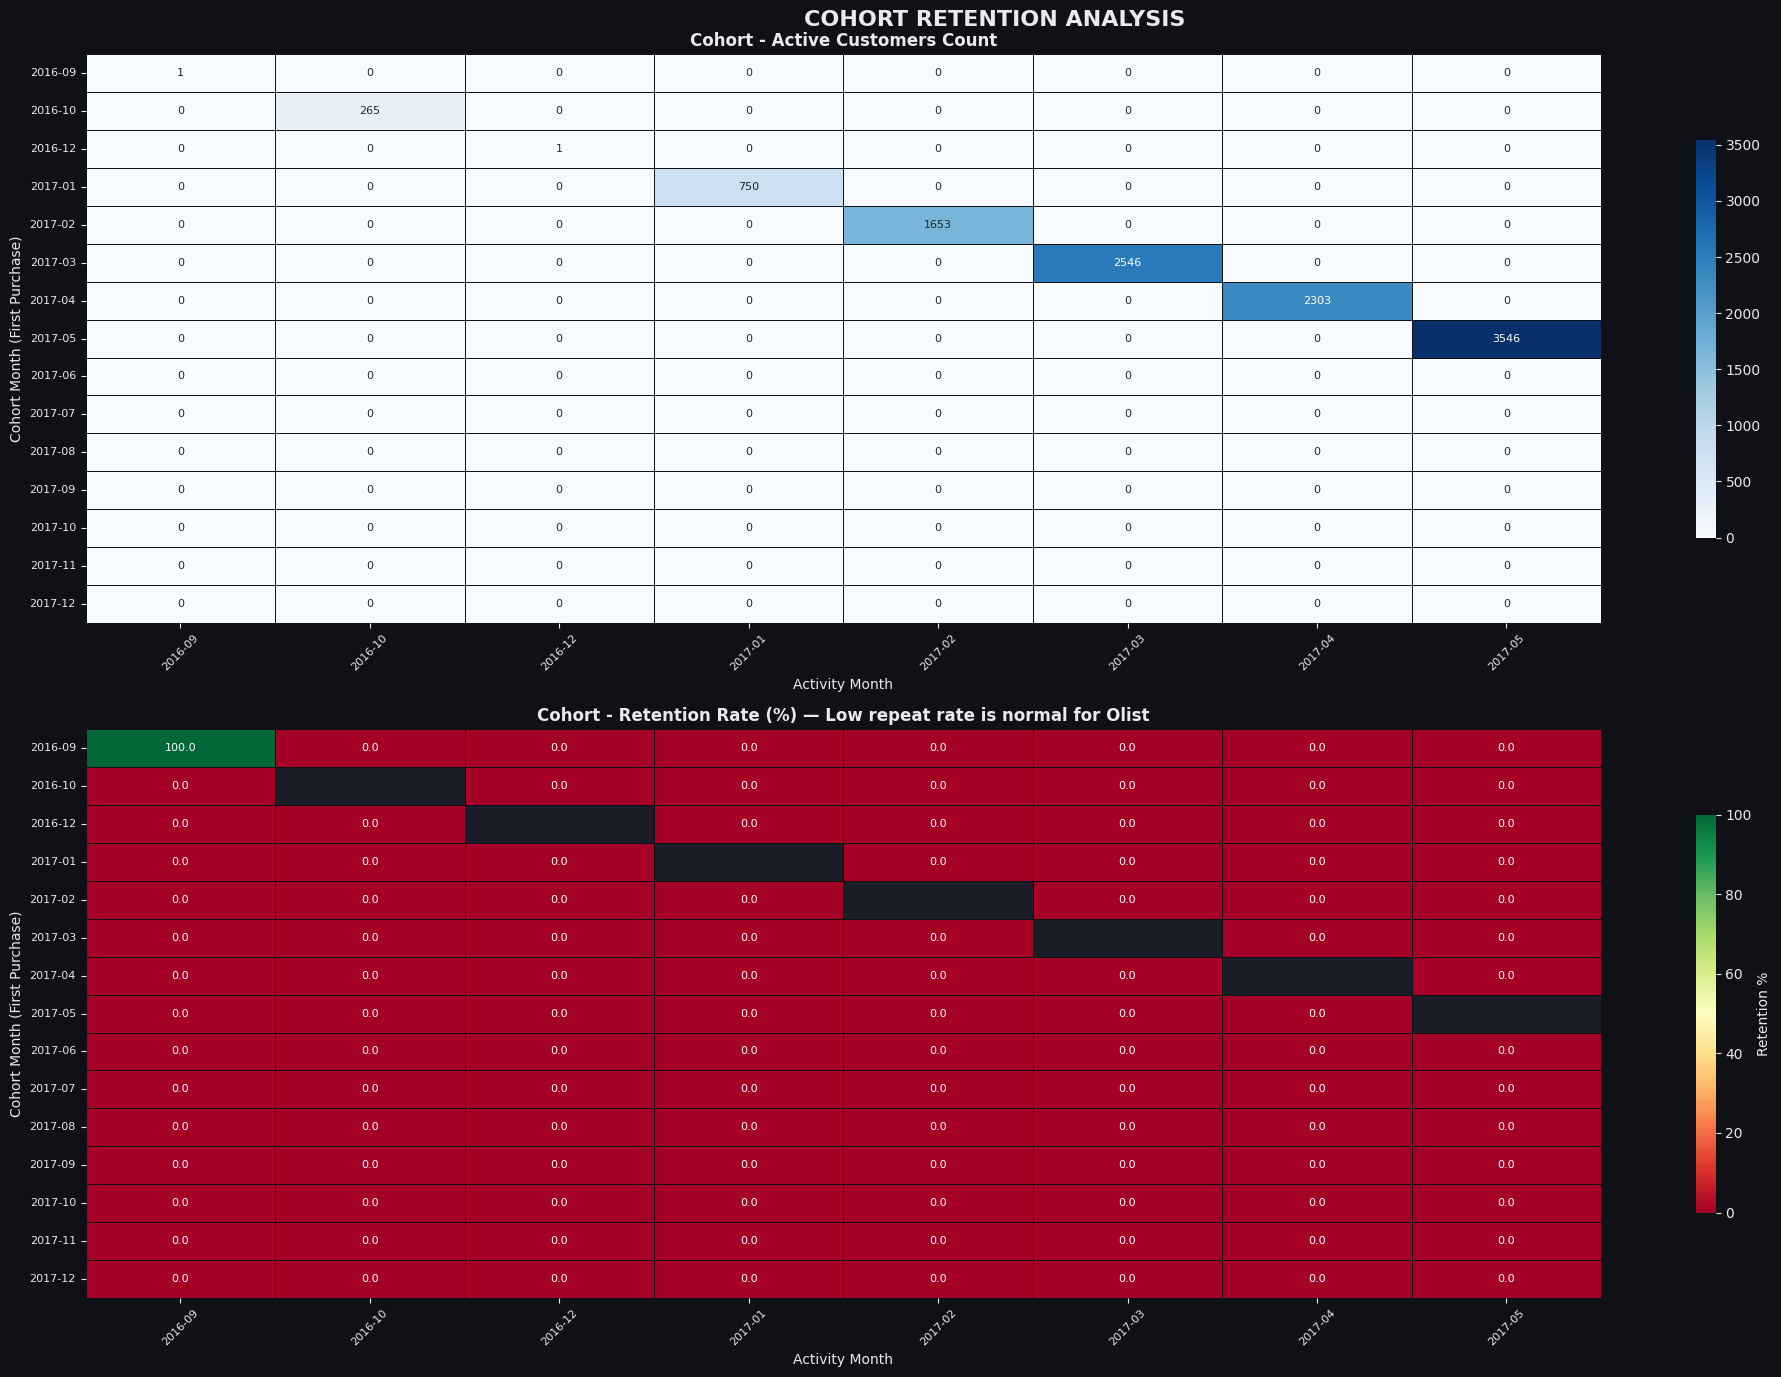


BUSINESS INSIGHT:
Olist customers have very low repeat purchase rate
Most customers buy only once (one time buyers)

This is common for marketplace platforms where:
- Customers buy from specific sellers directly
- No strong platform loyalty
- Price driven purchases

Recommendation:
- Launch loyalty program
- Send re-engagement emails
- Offer repeat purchase discounts



In [28]:
# Cohort Analysis
from src.sql_queries import get_cohort_data

df = get_cohort_data()

# Pivot cohort data
cohort_pivot = df.pivot_table(
    index="cohort_month",
    columns="activity_month",
    values="active_customers",
    aggfunc="sum"
)

# Keep top 15 cohorts and 8 months
cohort_pivot = cohort_pivot.iloc[:15, :8]

# Fill NaN with 0
cohort_pivot = cohort_pivot.fillna(0)

# Calculate retention rate
cohort_size = cohort_pivot.iloc[:, 0]
retention   = cohort_pivot.divide(cohort_size, axis=0) * 100
retention   = retention.fillna(0)

fig, axes = plt.subplots(2, 1, figsize=(20, 14), facecolor=BG)
fig.suptitle(
    "COHORT RETENTION ANALYSIS",
    fontsize=16, fontweight="bold", color=TEXT_C
)

# Plot 1: Absolute customer counts
ax = axes[0]
sns.heatmap(
    cohort_pivot,
    ax=ax,
    cmap="Blues",
    annot=True,
    fmt=".0f",
    annot_kws={"size": 8},
    linewidths=0.5,
    linecolor=BG,
    cbar_kws={"shrink": 0.7}
)
ax.set_title(
    "Cohort - Active Customers Count",
    color=TEXT_C
)
ax.set_xlabel("Activity Month")
ax.set_ylabel("Cohort Month (First Purchase)")
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.tick_params(axis="y", rotation=0,  labelsize=8)

# Plot 2: Retention rate
ax = axes[1]
sns.heatmap(
    retention,
    ax=ax,
    cmap="RdYlGn",
    annot=True,
    fmt=".1f",
    annot_kws={"size": 8},
    linewidths=0.5,
    linecolor=BG,
    vmin=0,
    vmax=100,
    cbar_kws={
        "shrink": 0.7,
        "label" : "Retention %"
    }
)
ax.set_title(
    "Cohort - Retention Rate (%) — Low repeat rate is normal for Olist",
    color=TEXT_C
)
ax.set_xlabel("Activity Month")
ax.set_ylabel("Cohort Month (First Purchase)")
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.tick_params(axis="y", rotation=0,  labelsize=8)

plt.tight_layout()
plt.show()

# Print insight
print("""
BUSINESS INSIGHT:
=================================================
Olist customers have very low repeat purchase rate
Most customers buy only once (one time buyers)

This is common for marketplace platforms where:
- Customers buy from specific sellers directly
- No strong platform loyalty
- Price driven purchases

Recommendation:
- Launch loyalty program
- Send re-engagement emails
- Offer repeat purchase discounts
""")

In [29]:
# EDA Summary
print("=" * 55)
print("   EDA COMPLETE - KEY BUSINESS INSIGHTS")
print("=" * 55)

print("""
REVENUE INSIGHTS:
-------------------------------------------------
- Total Revenue        : R$19,776,160
- Best Month           : November 2017 (Black Friday)
- Top Category         : Health & Beauty
- Top State            : Sao Paulo (SP) - 40% of revenue
- Southeast dominates  : 70%+ of all orders

CUSTOMER INSIGHTS:
-------------------------------------------------
- Total Customers      : 96,478
- One Time Buyers      : 97%+ of all customers
- Low Repeat Rate      : Major business problem
- Best Region          : Southeast Brazil
- Avg Order Value      : R$179.47

PRODUCT INSIGHTS:
-------------------------------------------------
- Total Products       : 32,951
- Top Category         : Health & Beauty
- Avg Review Score     : 4.08 out of 5
- 77% Positive Reviews : Strong satisfaction

DELIVERY INSIGHTS:
-------------------------------------------------
- Avg Delivery Days    : 12 days
- Worst State          : Roraima (RR) - 29+ days
- Best State           : Sao Paulo (SP) - 8 days
- Late Delivery Rate   : ~8% of orders

PAYMENT INSIGHTS:
-------------------------------------------------
- Credit Card          : 74% of orders
- Boleto               : 19% of orders
- Avg Installments     : 3.7 months
- Max Installments     : 24 months

SELLER INSIGHTS:
-------------------------------------------------
- Total Sellers        : 3,095
- Top Seller State     : Sao Paulo (SP)
- Avg Review Score     : 4.0+ for top sellers
- Late Delivery        : Key seller performance metric
""")

print("=" * 55)
print("   TOTAL EDA CELLS COMPLETED : 19")
print("   TOTAL PLOTS GENERATED     : 18")
print("=" * 55)

   EDA COMPLETE - KEY BUSINESS INSIGHTS

REVENUE INSIGHTS:
-------------------------------------------------
- Total Revenue        : R$19,776,160
- Best Month           : November 2017 (Black Friday)
- Top Category         : Health & Beauty
- Top State            : Sao Paulo (SP) - 40% of revenue
- Southeast dominates  : 70%+ of all orders

CUSTOMER INSIGHTS:
-------------------------------------------------
- Total Customers      : 96,478
- One Time Buyers      : 97%+ of all customers
- Low Repeat Rate      : Major business problem
- Best Region          : Southeast Brazil
- Avg Order Value      : R$179.47

PRODUCT INSIGHTS:
-------------------------------------------------
- Total Products       : 32,951
- Top Category         : Health & Beauty
- Avg Review Score     : 4.08 out of 5
- 77% Positive Reviews : Strong satisfaction

DELIVERY INSIGHTS:
-------------------------------------------------
- Avg Delivery Days    : 12 days
- Worst State          : Roraima (RR) - 29+ days
- Best